GRAPH 1 — Slide 5: Delivery Performance.

"On-Time vs. Delayed Orders" + "Distribution of Delivery Delays"

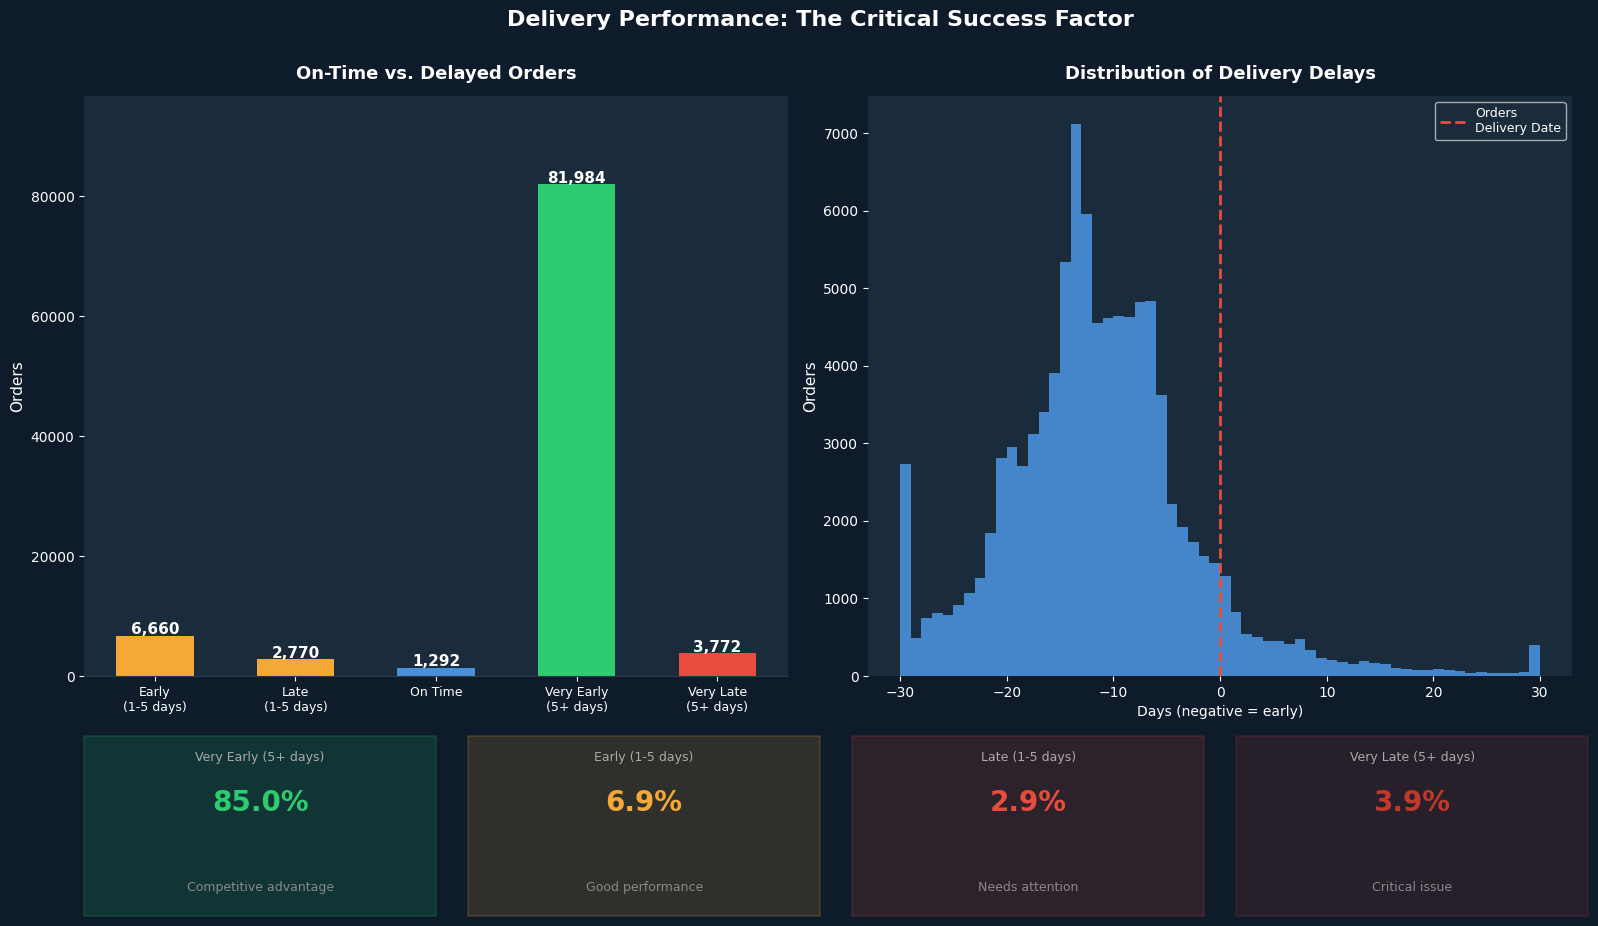

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import warnings
warnings.filterwarnings("ignore")

DATA_PATH = ""

# ── Load data
orders = pd.read_csv(DATA_PATH + "olist_orders_dataset.csv", on_bad_lines='skip')
orders["order_delivered_customer_date"]  = pd.to_datetime(orders["order_delivered_customer_date"],  errors="coerce")
orders["order_estimated_delivery_date"]  = pd.to_datetime(orders["order_estimated_delivery_date"],  errors="coerce")

delivered = orders[orders["order_status"] == "delivered"].copy()
delivered["delay_days"] = (
    delivered["order_delivered_customer_date"] -
    delivered["order_estimated_delivery_date"]
).dt.days.dropna()

# ── Classify delays
def classify(d):
    if   d <= -5: return "Very Early\n(5+ days)"
    elif d <   0: return "Early\n(1‑5 days)"
    elif d == 0:  return "On Time"
    elif d <=  5: return "Late\n(1‑5 days)"
    else:         return "Very Late\n(5+ days)"

delivered["cat"] = delivered["delay_days"].apply(classify)
cat_order  = ["Early\n(1‑5 days)", "Late\n(1‑5 days)", "On Time",
              "Very Early\n(5+ days)", "Very Late\n(5+ days)"]
cat_colors = ["#F4A836", "#F4A836", "#4A90D9", "#2ECC71", "#E74C3C"]
counts     = [delivered["cat"].value_counts().get(c, 0) for c in cat_order]
pcts       = [delivered["cat"].value_counts(normalize=True).get(c, 0) * 100
              for c in cat_order]

# ── Plot
BG   = "#0D1B2A"
CARD = "#1A2B3C"
plt.rcParams.update({"font.family": "DejaVu Sans"})

fig = plt.figure(figsize=(16, 10), facecolor=BG)

# ── Left: bar chart ───────────────────────────────────────────
ax1 = fig.add_axes([0.04, 0.28, 0.44, 0.58])
ax1.set_facecolor(CARD)
bars = ax1.bar(cat_order, counts, color=cat_colors, width=0.55, edgecolor="none")
for bar, cnt in zip(bars, counts):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 300,
             f"{cnt:,}", ha="center", color="white", fontsize=11, fontweight="bold")
ax1.set_ylim(0, max(counts) * 1.18)
ax1.set_ylabel("Orders", color="white", fontsize=11)
ax1.tick_params(colors="white")
ax1.spines[:].set_visible(False)
for spine in ["bottom"]:
    ax1.spines[spine].set_visible(True)
    ax1.spines[spine].set_color("#2A3B4C")
ax1.set_title("On-Time vs. Delayed Orders", color="white", fontsize=13,
              fontweight="bold", pad=12)
ax1.yaxis.label.set_color("white")
ax1.tick_params(axis="y", colors="white")
ax1.tick_params(axis="x", colors="white", labelsize=9)
ax1.set_facecolor(CARD)

# ── Right: histogram ──────────────────────────────────────────
ax2 = fig.add_axes([0.53, 0.28, 0.44, 0.58])
ax2.set_facecolor(CARD)
delay_clipped = delivered["delay_days"].clip(-30, 30)
ax2.hist(delay_clipped, bins=60, color="#4A90D9", edgecolor="none", alpha=0.9)
ax2.axvline(0, color="#E74C3C", linewidth=2, linestyle="--", label="Orders\nDelivery Date")
ax2.set_title("Distribution of Delivery Delays", color="white", fontsize=13,
              fontweight="bold", pad=12)
ax2.set_xlabel("Days (negative = early)", color="white", fontsize=10)
ax2.set_ylabel("Orders", color="white", fontsize=11)
ax2.tick_params(colors="white")
ax2.spines[:].set_visible(False)
ax2.legend(facecolor=CARD, labelcolor="white", fontsize=9)

# ── Stat cards at bottom ──────────────────────────────────────
card_data = [
    ("Very Early (5+ days)", f"{pcts[3]:.1f}%", "Competitive advantage", "#2ECC71"),
    ("Early (1‑5 days)",     f"{pcts[0]:.1f}%", "Good performance",       "#F4A836"),
    ("Late (1‑5 days)",      f"{pcts[1]:.1f}%", "Needs attention",         "#E74C3C"),
    ("Very Late (5+ days)",  f"{pcts[4]:.1f}%", "Critical issue",          "#C0392B"),
]
for i, (label, pct, sub, col) in enumerate(card_data):
    x = 0.04 + i * 0.24
    rect = plt.Rectangle((x, 0.04), 0.22, 0.18,
                          transform=fig.transFigure, facecolor=col, alpha=0.15,
                          linewidth=1.5, edgecolor=col)
    fig.add_artist(rect)
    fig.text(x + 0.11, 0.195, label, ha="center", color="#AAAAAA", fontsize=9,
             transform=fig.transFigure)
    fig.text(x + 0.11, 0.145, pct, ha="center", color=col, fontsize=20,
             fontweight="bold", transform=fig.transFigure)
    fig.text(x + 0.11, 0.065, sub, ha="center", color="#888888", fontsize=9,
             transform=fig.transFigure)

fig.text(0.5, 0.93, "Delivery Performance: The Critical Success Factor",
         ha="center", color="white", fontsize=16, fontweight="bold")

plt.savefig("graph1_slide5_delivery_performance.png", dpi=150,
            bbox_inches="tight", facecolor=BG)
plt.show()


 GRAPH 2 — Slide 7: Freight Cost Analysis

"Distribution of Freight Costs per Order"  +
"Freight Cost as % of Order Value"

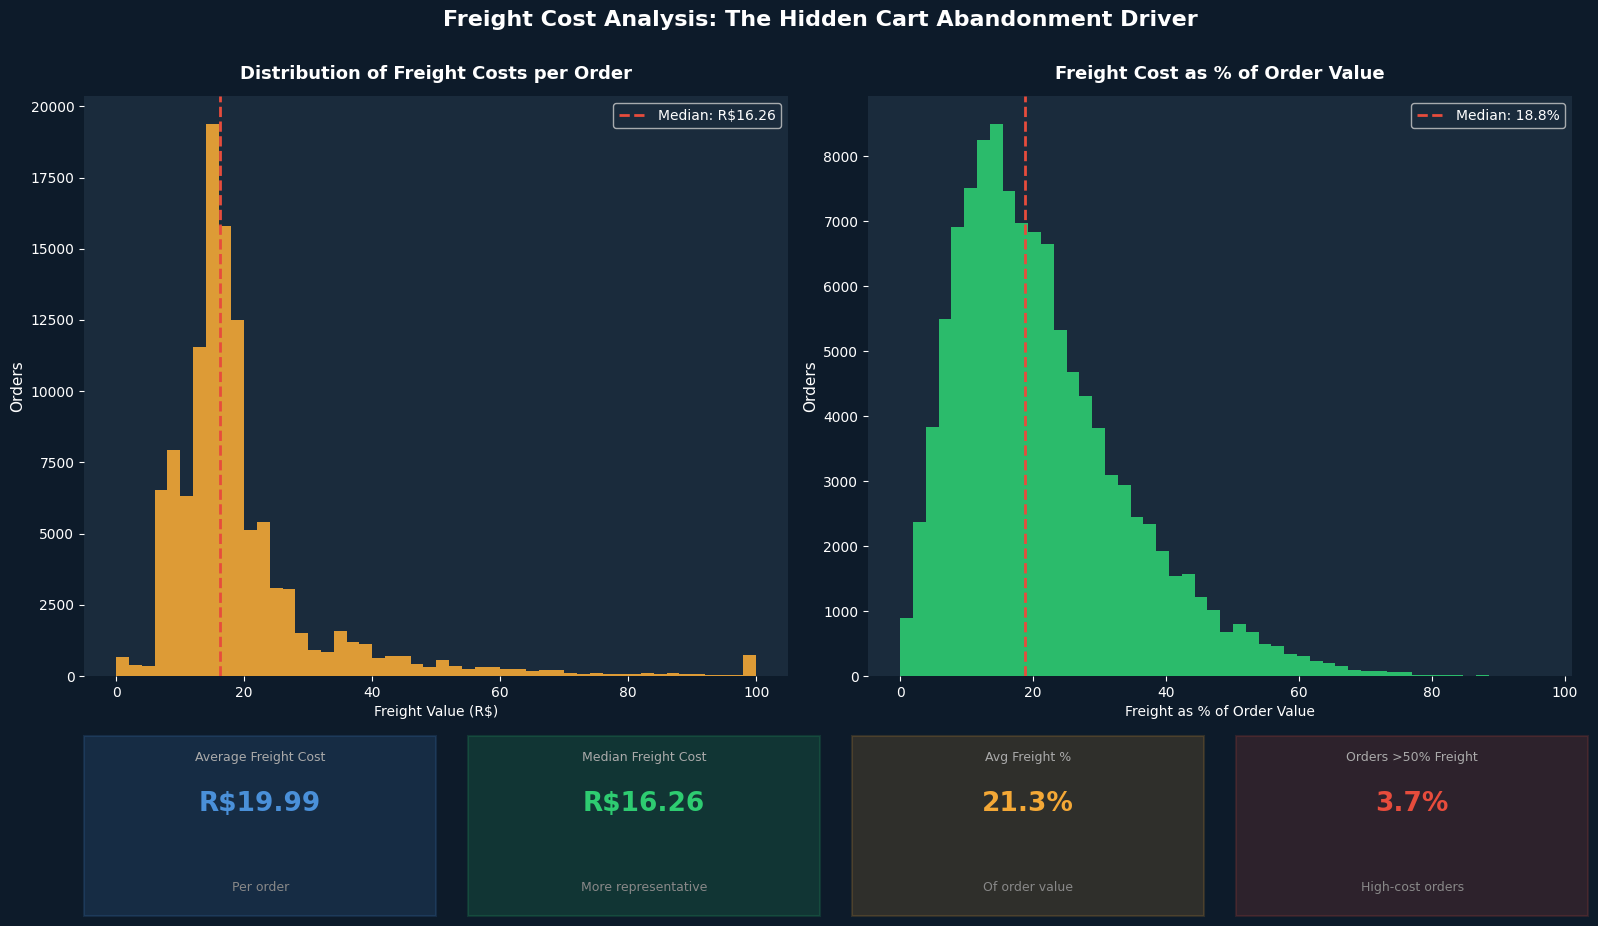

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

DATA_PATH = ""

items = pd.read_csv(DATA_PATH + "olist_order_items_dataset.csv")

# freight as % of order value
items["order_value"]  = items["price"] + items["freight_value"]
items["freight_pct"]  = (items["freight_value"] / items["order_value"] * 100
                         ).replace([np.inf, -np.inf], np.nan)

avg_freight = items["freight_value"].mean()
med_freight = items["freight_value"].median()
med_pct     = items["freight_pct"].dropna().median()
pct_over50  = (items["freight_pct"].dropna() > 50).mean() * 100

BG   = "#0D1B2A"
CARD = "#1A2B3C"
plt.rcParams.update({"font.family": "DejaVu Sans"})

fig = plt.figure(figsize=(16, 10), facecolor=BG)

# ── Left histogram: absolute freight ─────────────────────────
ax1 = fig.add_axes([0.04, 0.28, 0.44, 0.58])
ax1.set_facecolor(CARD)
ax1.hist(items["freight_value"].clip(0, 100), bins=50,
         color="#F4A836", edgecolor="none", alpha=0.9)
ax1.axvline(med_freight, color="#E74C3C", linewidth=2, linestyle="--",
            label=f"Median: R${med_freight:.2f}")
ax1.set_title("Distribution of Freight Costs per Order",
              color="white", fontsize=13, fontweight="bold", pad=12)
ax1.set_xlabel("Freight Value (R$)", color="white", fontsize=10)
ax1.set_ylabel("Orders", color="white", fontsize=11)
ax1.tick_params(colors="white")
ax1.spines[:].set_visible(False)
ax1.legend(facecolor=CARD, labelcolor="white", fontsize=10)
ax1.set_facecolor(CARD)

# ── Right histogram: freight % ────────────────────────────────
ax2 = fig.add_axes([0.53, 0.28, 0.44, 0.58])
ax2.set_facecolor(CARD)
ax2.hist(items["freight_pct"].dropna().clip(0, 100), bins=50,
         color="#2ECC71", edgecolor="none", alpha=0.9)
ax2.axvline(med_pct, color="#E74C3C", linewidth=2, linestyle="--",
            label=f"Median: {med_pct:.1f}%")
ax2.set_title("Freight Cost as % of Order Value",
              color="white", fontsize=13, fontweight="bold", pad=12)
ax2.set_xlabel("Freight as % of Order Value", color="white", fontsize=10)
ax2.set_ylabel("Orders", color="white", fontsize=11)
ax2.tick_params(colors="white")
ax2.spines[:].set_visible(False)
ax2.legend(facecolor=CARD, labelcolor="white", fontsize=10)
ax2.set_facecolor(CARD)

# ── Stat cards ────────────────────────────────────────────────
card_data = [
    ("Average Freight Cost",  f"R${avg_freight:.2f}", "Per order",           "#4A90D9"),
    ("Median Freight Cost",   f"R${med_freight:.2f}", "More representative", "#2ECC71"),
    ("Avg Freight %",         f"{items['freight_pct'].dropna().mean():.1f}%",
                               "Of order value",                               "#F4A836"),
    ("Orders >50% Freight",   f"{pct_over50:.1f}%",  "High-cost orders",     "#E74C3C"),
]
for i, (label, val, sub, col) in enumerate(card_data):
    x = 0.04 + i * 0.24
    rect = plt.Rectangle((x, 0.04), 0.22, 0.18,
                          transform=fig.transFigure, facecolor=col, alpha=0.15,
                          linewidth=1.5, edgecolor=col)
    fig.add_artist(rect)
    fig.text(x + 0.11, 0.195, label, ha="center", color="#AAAAAA", fontsize=9,
             transform=fig.transFigure)
    fig.text(x + 0.11, 0.145, val, ha="center", color=col, fontsize=19,
             fontweight="bold", transform=fig.transFigure)
    fig.text(x + 0.11, 0.065, sub, ha="center", color="#888888", fontsize=9,
             transform=fig.transFigure)

fig.text(0.5, 0.93,
         "Freight Cost Analysis: The Hidden Cart Abandonment Driver",
         ha="center", color="white", fontsize=16, fontweight="bold")

plt.savefig("graph2_slide7_freight_cost.png", dpi=150,
            bbox_inches="tight", facecolor=BG)
plt.show()

GRAPH 3 — Slide 8: Category-Level Freight Impact

Top 10 Categories: Highest Freight %

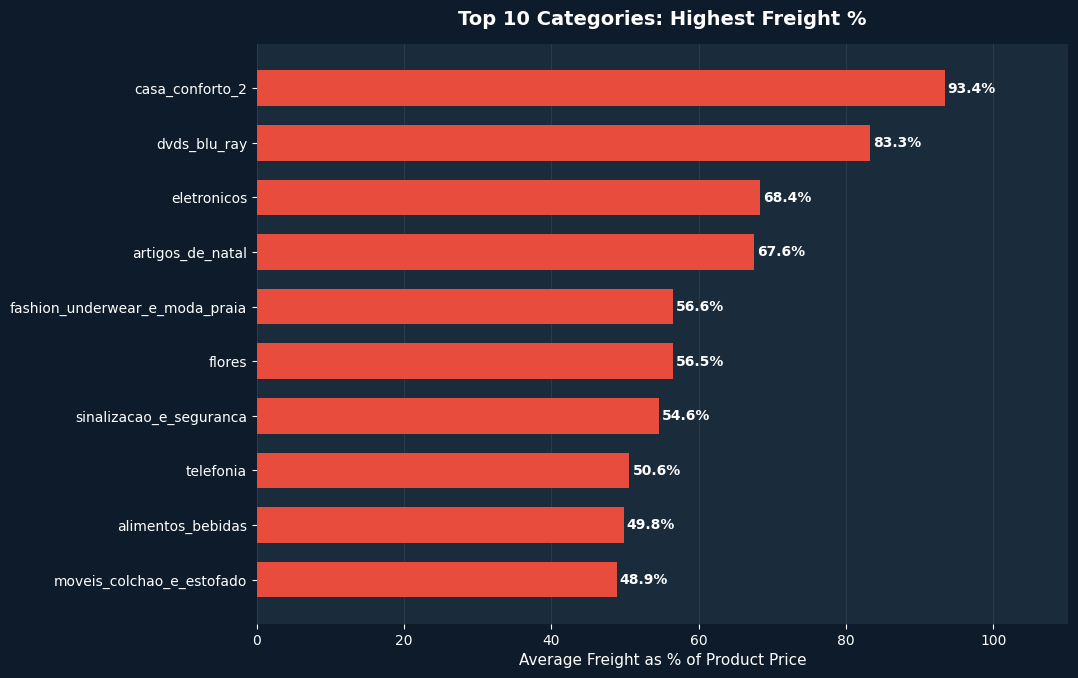

In [14]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

DATA_PATH = ""

items    = pd.read_csv(DATA_PATH + "olist_order_items_dataset.csv")
products = pd.read_csv(DATA_PATH + "olist_products_dataset.csv")

items = items.merge(products[["product_id", "product_category_name"]],
                    on="product_id", how="left")

# freight % of product price (matches PPTX axis label)
items["freight_pct"] = (items["freight_value"] / items["price"] * 100
                        ).replace([np.inf, -np.inf], np.nan)

top10 = (items.groupby("product_category_name")["freight_pct"]
         .mean()
         .dropna()
         .nlargest(10)
         .sort_values(ascending=True))   # ascending so longest bar is on top

BG   = "#0D1B2A"
CARD = "#1A2B3C"
plt.rcParams.update({"font.family": "DejaVu Sans"})

fig, ax = plt.subplots(figsize=(11, 7), facecolor=BG)
ax.set_facecolor(CARD)

bars = ax.barh(top10.index, top10.values,
               color="#E74C3C", edgecolor="none", height=0.65)

for bar, val in zip(bars, top10.values):
    ax.text(val + 0.4, bar.get_y() + bar.get_height() / 2,
            f"{val:.1f}%", va="center", color="white",
            fontsize=10, fontweight="bold")

ax.set_xlabel("Average Freight as % of Product Price",
              color="white", fontsize=11)
ax.set_title("Top 10 Categories: Highest Freight %",
             color="white", fontsize=14, fontweight="bold", pad=14)
ax.tick_params(colors="white", labelsize=10)
ax.spines[:].set_visible(False)
ax.set_xlim(0, top10.values.max() * 1.18)

# faint grid
ax.xaxis.grid(True, color="#2A3B4C", linewidth=0.8)
ax.set_axisbelow(True)

fig.patch.set_facecolor(BG)
plt.tight_layout(pad=1.5)
plt.savefig("graph3_slide8_category_freight.png", dpi=150,
            bbox_inches="tight", facecolor=BG)
plt.show()

GRAPH 4 — Slide 10: Payment Method Distribution

Left : "Payment Methods Used by Brazilian Shoppers" (bar)

Right: Credit Card installments bar chart

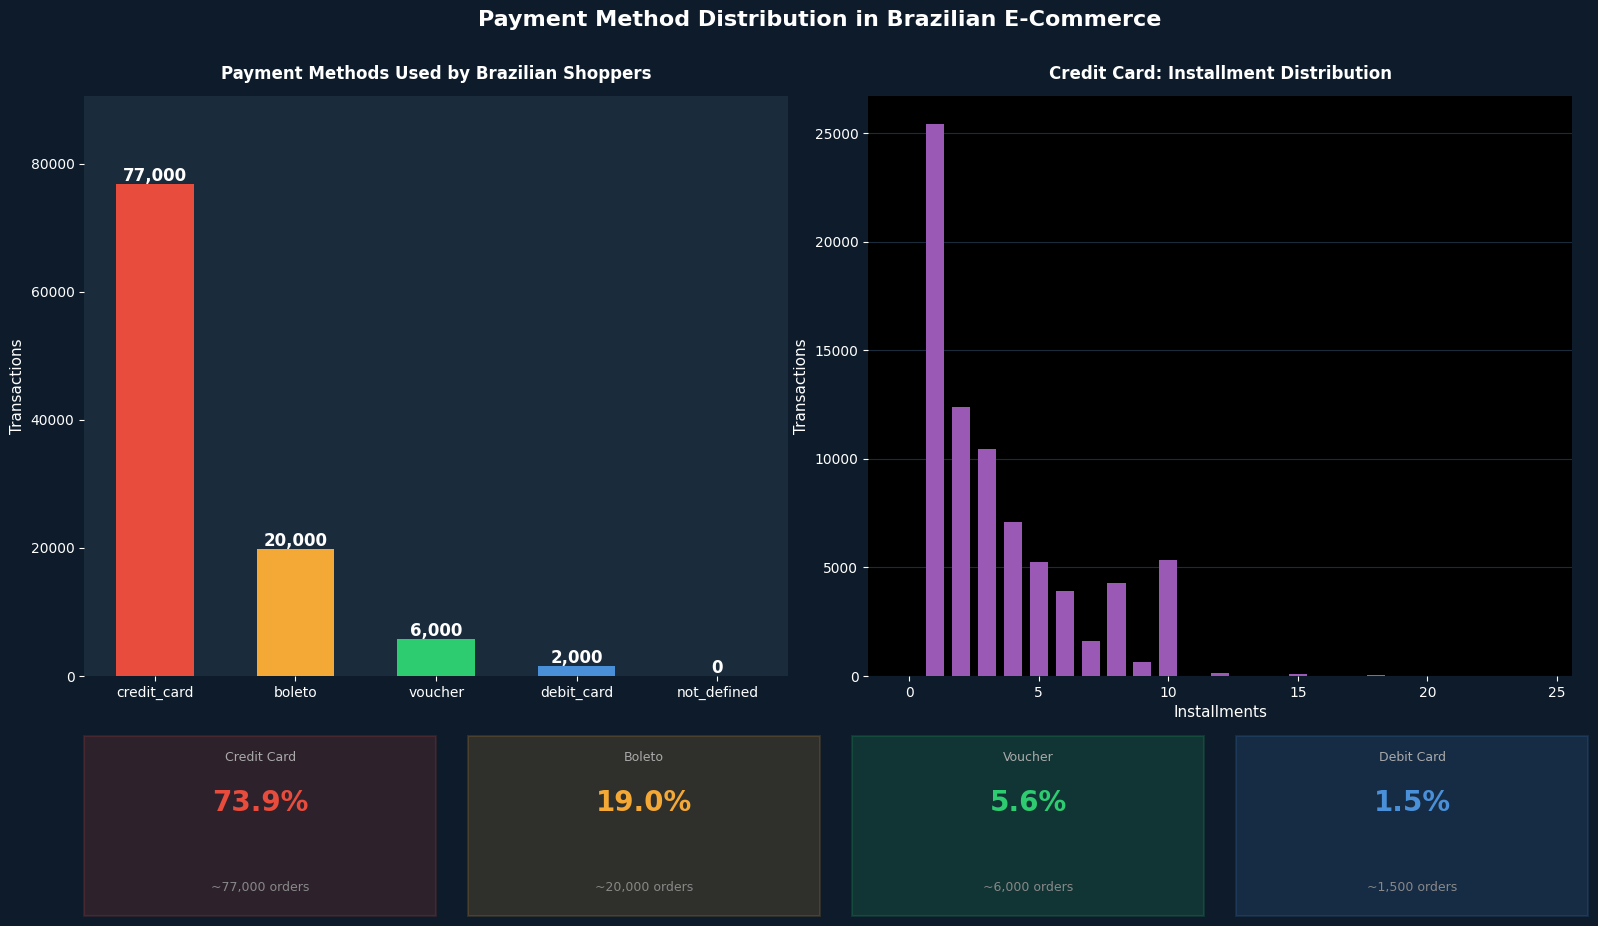

In [15]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

DATA_PATH = ""

payments = pd.read_csv(DATA_PATH + "olist_order_payments_dataset.csv")

pay_counts = payments["payment_type"].value_counts()

cc_installs = (payments[payments["payment_type"] == "credit_card"]
               ["payment_installments"].value_counts().sort_index())

BG   = "#0D1B2A"
CARD = "#1A2B3C"
plt.rcParams.update({"font.family": "DejaVu Sans"})

# match PPTX colors: credit_card=red, boleto=orange, voucher=teal, debit=blue
COLOR_MAP = {
    "credit_card": "#E74C3C",
    "boleto":      "#F4A836",
    "voucher":     "#2ECC71",
    "debit_card":  "#4A90D9",
}
bar_colors = [COLOR_MAP.get(t, "#888") for t in pay_counts.index]

fig = plt.figure(figsize=(16, 10), facecolor=BG)

# ── Left bar chart ────────────────────────────────────────────
ax1 = fig.add_axes([0.04, 0.28, 0.44, 0.58])
ax1.set_facecolor(CARD)
bars = ax1.bar(pay_counts.index, pay_counts.values,
               color=bar_colors, edgecolor="none", width=0.55)
for bar, val in zip(bars, pay_counts.values):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 500,
             f"{round(val/1000)*1000:,}", ha="center",
             color="white", fontsize=12, fontweight="bold")
ax1.set_ylim(0, pay_counts.max() * 1.18)
ax1.set_ylabel("Transactions", color="white", fontsize=11)
ax1.set_title("Payment Methods Used by Brazilian Shoppers",
              color="white", fontsize=12, fontweight="bold", pad=12)
ax1.tick_params(colors="white", labelsize=10)
ax1.spines[:].set_visible(False)
ax1.set_facecolor(CARD)

# ── Right: installments bar ───────────────────────────────────
ax2 = fig.add_axes([0.53, 0.28, 0.44, 0.58])
ax2.set_facecolor("#000000")
ax2.bar(cc_installs.index, cc_installs.values,
        color="#9B59B6", edgecolor="none", width=0.7)
ax2.set_xlabel("Installments", color="white", fontsize=11)
ax2.set_ylabel("Transactions", color="white", fontsize=11)
ax2.set_title("Credit Card: Installment Distribution",
              color="white", fontsize=12, fontweight="bold", pad=12)
ax2.tick_params(colors="white", labelsize=10)
ax2.spines[:].set_visible(False)
ax2.set_facecolor("#000000")
ax2.yaxis.grid(True, color="#1A2B3C", linewidth=0.8)
ax2.set_axisbelow(True)

# ── Stat cards ────────────────────────────────────────────────
card_data = [
    ("Credit Card", f"{pay_counts.get('credit_card',0)/pay_counts.sum()*100:.1f}%",
     "~77,000 orders", "#E74C3C"),
    ("Boleto",      f"{pay_counts.get('boleto',0)/pay_counts.sum()*100:.1f}%",
     "~20,000 orders", "#F4A836"),
    ("Voucher",     f"{pay_counts.get('voucher',0)/pay_counts.sum()*100:.1f}%",
     "~6,000 orders",  "#2ECC71"),
    ("Debit Card",  f"{pay_counts.get('debit_card',0)/pay_counts.sum()*100:.1f}%",
     "~1,500 orders",  "#4A90D9"),
]
for i, (label, pct, sub, col) in enumerate(card_data):
    x = 0.04 + i * 0.24
    rect = plt.Rectangle((x, 0.04), 0.22, 0.18,
                          transform=fig.transFigure, facecolor=col, alpha=0.15,
                          linewidth=1.5, edgecolor=col)
    fig.add_artist(rect)
    fig.text(x + 0.11, 0.195, label, ha="center", color="#AAAAAA", fontsize=9,
             transform=fig.transFigure)
    fig.text(x + 0.11, 0.145, pct, ha="center", color=col, fontsize=20,
             fontweight="bold", transform=fig.transFigure)
    fig.text(x + 0.11, 0.065, sub, ha="center", color="#888888", fontsize=9,
             transform=fig.transFigure)

fig.text(0.5, 0.93,
         "Payment Method Distribution in Brazilian E-Commerce",
         ha="center", color="white", fontsize=16, fontweight="bold")

plt.savefig("graph4_slide10_payment_distribution.png", dpi=150,
            bbox_inches="tight", facecolor=BG)
plt.show()

GRAPH 5 — Slide 12: Order Value Distribution by Payment Type

Violin Plot — Order Value Distribution by Payment Type

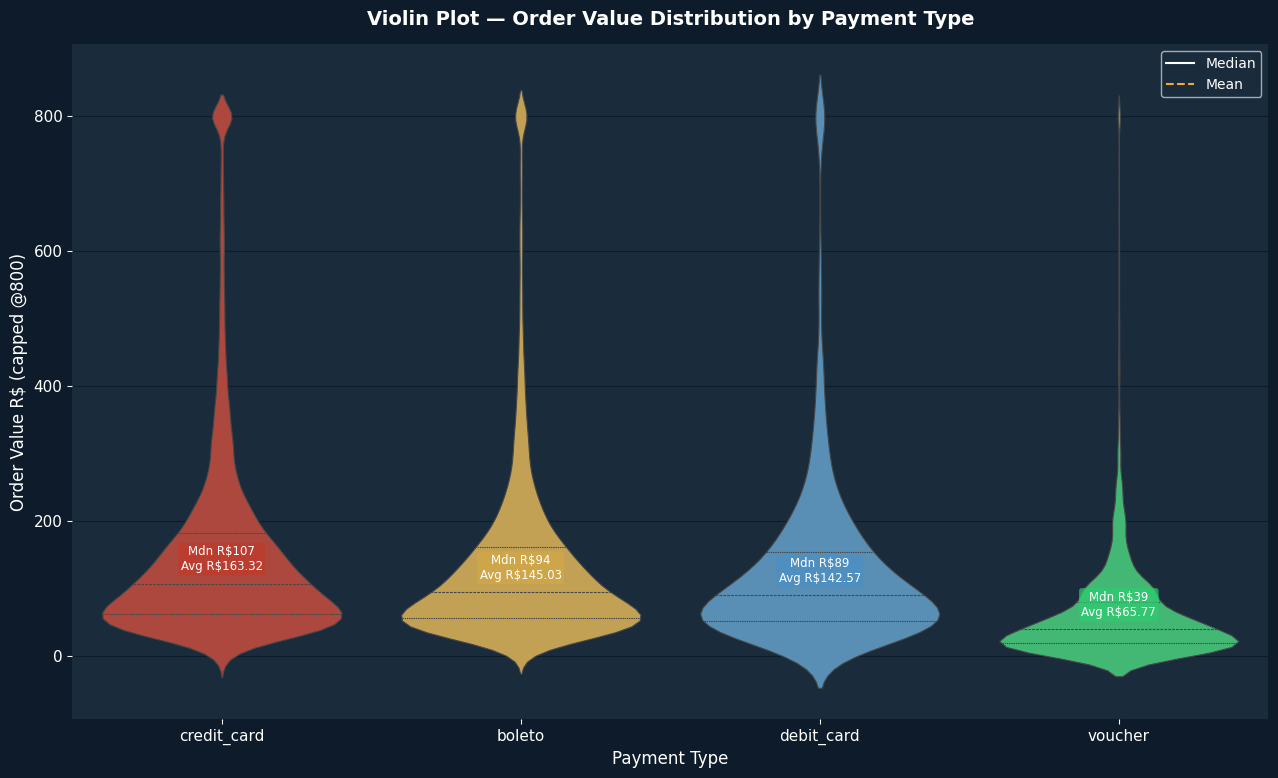

In [16]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

DATA_PATH = ""

payments = pd.read_csv(DATA_PATH + "olist_order_payments_dataset.csv")

pay_top4 = ["credit_card", "boleto", "debit_card", "voucher"]
df = payments[payments["payment_type"].isin(pay_top4)].copy()
df = df[df["payment_value"] > 0]
df["payment_value_capped"] = df["payment_value"].clip(upper=800)

# matching PPTX violin colors
VIOLIN_PALETTE = {
    "credit_card": "#C0392B",
    "boleto":      "#D4A843",
    "debit_card":  "#4A90C4",
    "voucher":     "#2ECC71",
}

BG   = "#0D1B2A"
CARD = "#1A2B3C"
plt.rcParams.update({"font.family": "DejaVu Sans"})

fig, ax = plt.subplots(figsize=(13, 8), facecolor=BG)
ax.set_facecolor(CARD)

sns.violinplot(
    data=df, x="payment_type", y="payment_value_capped",
    order=pay_top4,
    palette=VIOLIN_PALETTE,
    inner="quartile",
    linewidth=0.8,
    ax=ax,
)

# median & mean annotations
medians = df.groupby("payment_type")["payment_value"].median()
means   = df.groupby("payment_type")["payment_value"].mean()
for i, pt in enumerate(pay_top4):
    mdn = medians[pt]
    avg = means[pt]
    ax.text(i, mdn + 20, f"Mdn R${mdn:.0f}\nAvg R${avg:.2f}",
            ha="center", color="white", fontsize=8.5,
            bbox=dict(boxstyle="round,pad=0.2",
                      fc=VIOLIN_PALETTE[pt], alpha=0.7, lw=0))

# custom legend
from matplotlib.lines import Line2D
legend_elems = [
    Line2D([0], [0], color="white",  linewidth=1.5, label="Median"),
    Line2D([0], [0], color="#F4A836", linewidth=1.5, linestyle="--", label="Mean"),
]
ax.legend(handles=legend_elems, facecolor=CARD, labelcolor="white", fontsize=10)

ax.set_title("Violin Plot — Order Value Distribution by Payment Type",
             color="white", fontsize=14, fontweight="bold", pad=14)
ax.set_xlabel("Payment Type", color="white", fontsize=12)
ax.set_ylabel("Order Value R$ (capped @800)", color="white", fontsize=12)
ax.tick_params(colors="white", labelsize=11)
ax.spines[:].set_visible(False)
ax.yaxis.grid(True, color="#0D1B2A", linewidth=0.8)
ax.set_axisbelow(True)

plt.tight_layout(pad=1.5)
plt.savefig("graph5_slide12_violin_plot.png", dpi=150,
            bbox_inches="tight", facecolor=BG)
plt.show()


GRAPH 6 — Slide 13: Revenue Share & Order Value Analysis

 Left : Donut — "Revenue Share by Payment Type"

Right: Bar   — "Average Order Value by Payment"



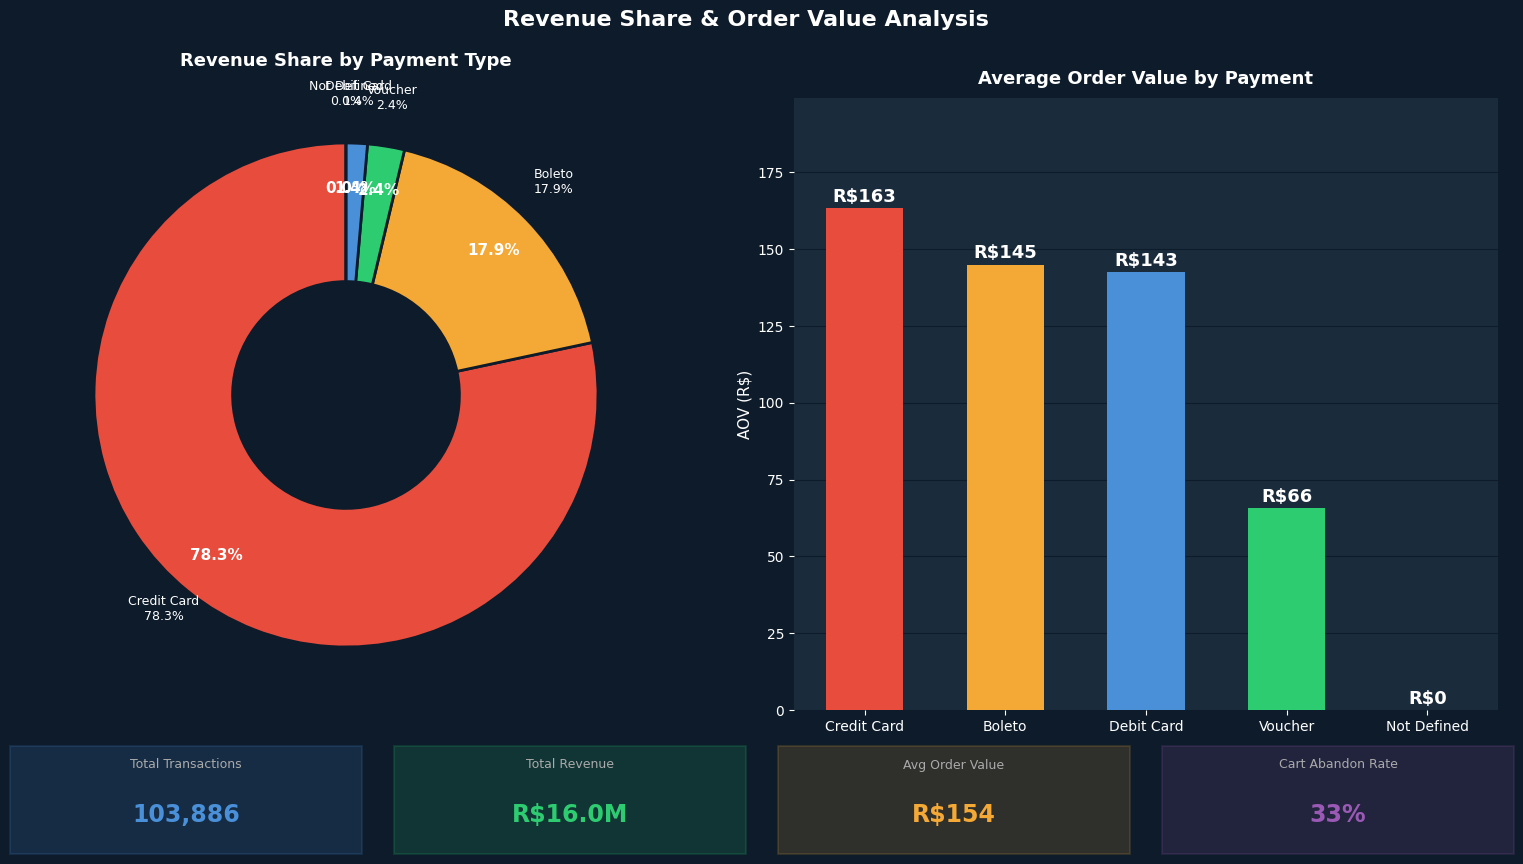

In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

DATA_PATH = ""

payments = pd.read_csv(DATA_PATH + "olist_order_payments_dataset.csv")

pay_perf = (payments.groupby("payment_type")
            .agg(total_orders=("order_id", "count"),
                 total_revenue=("payment_value", "sum"),
                 avg_order_value=("payment_value", "mean"))
            .reset_index())
pay_perf["revenue_share"] = pay_perf["total_revenue"] / pay_perf["total_revenue"].sum() * 100

# sort by revenue for donut
pay_perf = pay_perf.sort_values("total_revenue", ascending=False)

COLOR_MAP = {
    "credit_card": "#E74C3C",
    "boleto":      "#F4A836",
    "voucher":     "#2ECC71",
    "debit_card":  "#4A90D9",
}
colors = [COLOR_MAP.get(t, "#888") for t in pay_perf["payment_type"]]

BG   = "#0D1B2A"
CARD = "#1A2B3C"
plt.rcParams.update({"font.family": "DejaVu Sans"})

fig = plt.figure(figsize=(16, 9), facecolor=BG)

# ── Left: donut ───────────────────────────────────────────────
ax1 = fig.add_axes([0.02, 0.18, 0.46, 0.70])
ax1.set_facecolor(CARD)
wedges, texts, autotexts = ax1.pie(
    pay_perf["total_revenue"],
    labels=None,
    colors=colors,
    autopct="%1.1f%%",
    startangle=90,
    pctdistance=0.82,
    wedgeprops=dict(width=0.55, edgecolor=BG, linewidth=2),
)
for at in autotexts:
    at.set_color("white"); at.set_fontsize(11); at.set_fontweight("bold")

# manual labels outside
for i, (wedge, row) in enumerate(zip(wedges, pay_perf.itertuples())):
    angle = (wedge.theta2 + wedge.theta1) / 2
    x = 1.15 * np.cos(np.radians(angle))
    y = 1.15 * np.sin(np.radians(angle))
    ax1.text(x, y,
             f"{row.payment_type.replace('_',' ').title()}\n{row.revenue_share:.1f}%",
             ha="center", color="white", fontsize=9)

ax1.set_title("Revenue Share by Payment Type",
              color="white", fontsize=13, fontweight="bold", pad=10)
ax1.set_facecolor(CARD)

# ── Right: bar AOV ────────────────────────────────────────────
ax2 = fig.add_axes([0.53, 0.18, 0.44, 0.68])
ax2.set_facecolor(CARD)
pay_sorted = pay_perf.sort_values("avg_order_value", ascending=False)
bar_c = [COLOR_MAP.get(t, "#888") for t in pay_sorted["payment_type"]]
bars = ax2.bar(
    [t.replace("_", " ").title() for t in pay_sorted["payment_type"]],
    pay_sorted["avg_order_value"],
    color=bar_c, edgecolor="none", width=0.55,
)
for bar, val in zip(bars, pay_sorted["avg_order_value"]):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2,
             f"R${val:.0f}", ha="center", color="white",
             fontsize=13, fontweight="bold")

ax2.set_ylim(0, pay_sorted["avg_order_value"].max() * 1.22)
ax2.set_ylabel("AOV (R$)", color="white", fontsize=11)
ax2.set_title("Average Order Value by Payment",
              color="white", fontsize=13, fontweight="bold", pad=10)
ax2.tick_params(colors="white", labelsize=10)
ax2.spines[:].set_visible(False)
ax2.yaxis.grid(True, color="#0D1B2A", linewidth=0.8)
ax2.set_axisbelow(True)
ax2.set_facecolor(CARD)

# ── Bottom stat cards ─────────────────────────────────────────
total_tx  = payments["order_id"].count()
total_rev = payments["payment_value"].sum()
avg_ov    = payments["payment_value"].mean()

card_data = [
    ("Total Transactions", f"{total_tx:,}",         "#4A90D9"),
    ("Total Revenue",      f"R${total_rev/1e6:.1f}M","#2ECC71"),
    ("Avg Order Value",    f"R${avg_ov:.0f}",        "#F4A836"),
    ("Cart Abandon Rate",  "33%",                    "#9B59B6"),
]
for i, (label, val, col) in enumerate(card_data):
    x = 0.04 + i * 0.24
    rect = plt.Rectangle((x, 0.02), 0.22, 0.12,
                          transform=fig.transFigure, facecolor=col, alpha=0.15,
                          linewidth=1.5, edgecolor=col)
    fig.add_artist(rect)
    fig.text(x + 0.11, 0.115, label, ha="center", color="#AAAAAA", fontsize=9,
             transform=fig.transFigure)
    fig.text(x + 0.11, 0.055, val, ha="center", color=col, fontsize=17,
             fontweight="bold", transform=fig.transFigure)

fig.text(0.5, 0.94, "Revenue Share & Order Value Analysis",
         ha="center", color="white", fontsize=16, fontweight="bold")

plt.savefig("graph6_slide13_revenue_aov.png", dpi=150,
            bbox_inches="tight", facecolor=BG)
plt.show()

GRAPH 7 — Slide 14: Order Value Buckets & Installment Correlation

Left : Stacked bar — "Order Value Bucket Distribution per Payment Type"

Right: Scatter    — "Credit Card: Order Value vs Installments"

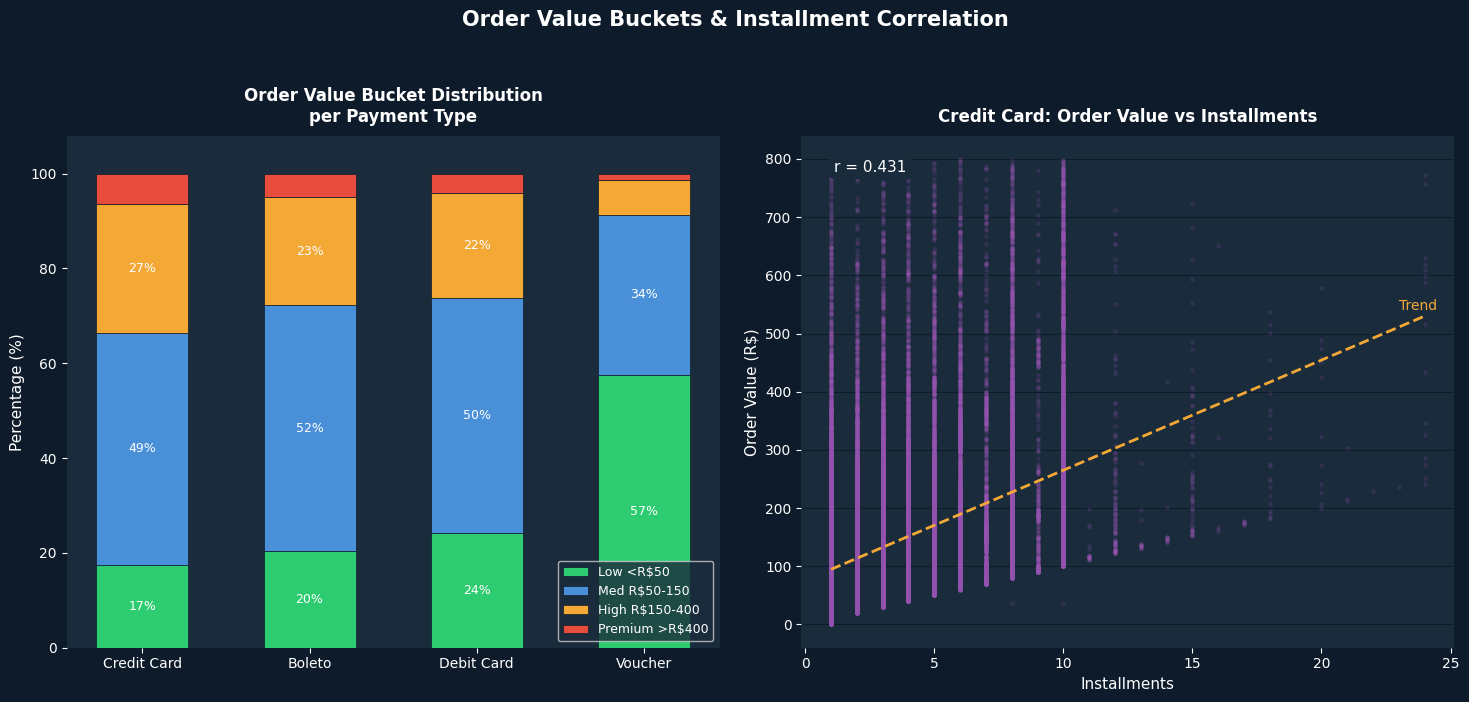

In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
import warnings
warnings.filterwarnings("ignore")

DATA_PATH = ""

payments = pd.read_csv(DATA_PATH + "olist_order_payments_dataset.csv")

# Bucket boundaries matching PPTX legend
def bucket(v):
    if   v <  50:  return "Low <R$50"
    elif v < 150:  return "Med R$50-150"
    elif v < 400:  return "High R$150-400"
    else:          return "Premium >R$400"

payments["bucket"] = payments["payment_value"].apply(bucket)
bucket_order = ["Low <R$50", "Med R$50-150", "High R$150-400", "Premium >R$400"]
bkt_colors   = ["#2ECC71", "#4A90D9", "#F4A836", "#E74C3C"]

pay_top4 = ["credit_card", "boleto", "debit_card", "voucher"]
pivot = (payments[payments["payment_type"].isin(pay_top4)]
         .groupby(["payment_type", "bucket"]).size()
         .unstack(fill_value=0)[bucket_order])

# normalise to %
pivot_pct = pivot.div(pivot.sum(axis=1), axis=0) * 100

cc = payments[(payments["payment_type"] == "credit_card") &
              (payments["payment_installments"] > 0) &
              (payments["payment_value"] < 800)].copy()
m, b, r, _, _ = stats.linregress(cc["payment_installments"], cc["payment_value"])

BG   = "#0D1B2A"
CARD = "#1A2B3C"
plt.rcParams.update({"font.family": "DejaVu Sans"})

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 7), facecolor=BG)

# ── Left: stacked bar ─────────────────────────────────────────
ax1.set_facecolor(CARD)
bottom = np.zeros(len(pay_top4))
x_pos  = np.arange(len(pay_top4))
for bkt, col in zip(bucket_order, bkt_colors):
    vals = pivot_pct.reindex(pay_top4)[bkt].values
    ax1.bar(x_pos, vals, bottom=bottom, color=col, edgecolor=BG,
            linewidth=0.5, width=0.55, label=bkt)
    for xi, (v, bot) in enumerate(zip(vals, bottom)):
        if v > 8:
            ax1.text(xi, bot + v/2, f"{v:.0f}%",
                     ha="center", va="center", color="white", fontsize=9)
    bottom += vals

ax1.set_xticks(x_pos)
ax1.set_xticklabels([t.replace("_", " ").title() for t in pay_top4],
                    color="white", fontsize=10)
ax1.set_ylabel("Percentage (%)", color="white", fontsize=11)
ax1.set_ylim(0, 108)
ax1.set_title("Order Value Bucket Distribution\nper Payment Type",
              color="white", fontsize=12, fontweight="bold", pad=10)
ax1.tick_params(colors="white")
ax1.spines[:].set_visible(False)
ax1.legend(facecolor=CARD, labelcolor="white", fontsize=9,
           loc="lower right")
ax1.set_facecolor(CARD)

# ── Right: scatter ────────────────────────────────────────────
ax2.set_facecolor(CARD)
ax2.scatter(cc["payment_installments"], cc["payment_value"],
            alpha=0.12, color="#9B59B6", s=6)
x_line = np.array([cc["payment_installments"].min(),
                   cc["payment_installments"].max()])
ax2.plot(x_line, m * x_line + b, color="#F4A836", linewidth=2,
         linestyle="--", label="Trend")
ax2.text(x_line.max() - 1, m * x_line.max() + b + 10,
         "Trend", color="#F4A836", fontsize=10)
ax2.set_xlabel("Installments", color="white", fontsize=11)
ax2.set_ylabel("Order Value (R$)", color="white", fontsize=11)
ax2.set_title("Credit Card: Order Value vs Installments",
              color="white", fontsize=12, fontweight="bold", pad=10)
ax2.tick_params(colors="white")
ax2.spines[:].set_visible(False)
ax2.yaxis.grid(True, color="#0D1B2A", linewidth=0.7)
ax2.set_axisbelow(True)
ax2.set_facecolor(CARD)

# r value annotation
ax2.text(0.05, 0.93, f"r = {r:.3f}", transform=ax2.transAxes,
         color="white", fontsize=11,
         bbox=dict(boxstyle="round,pad=0.3", fc="#1A2B3C", lw=0))

fig.suptitle("Order Value Buckets & Installment Correlation",
             color="white", fontsize=15, fontweight="bold", y=1.01)
plt.tight_layout(pad=1.8)
plt.savefig("graph7_slide14_buckets_installments.png", dpi=150,
            bbox_inches="tight", facecolor=BG)
plt.show()

GRAPH 8 — Slide 15: Payment Flow Visualization (Sankey-style)

Payment Type → Order Value Range → Installment Plan Flow

Uses NetworkX to draw nodes + curved edges as in PPTX.

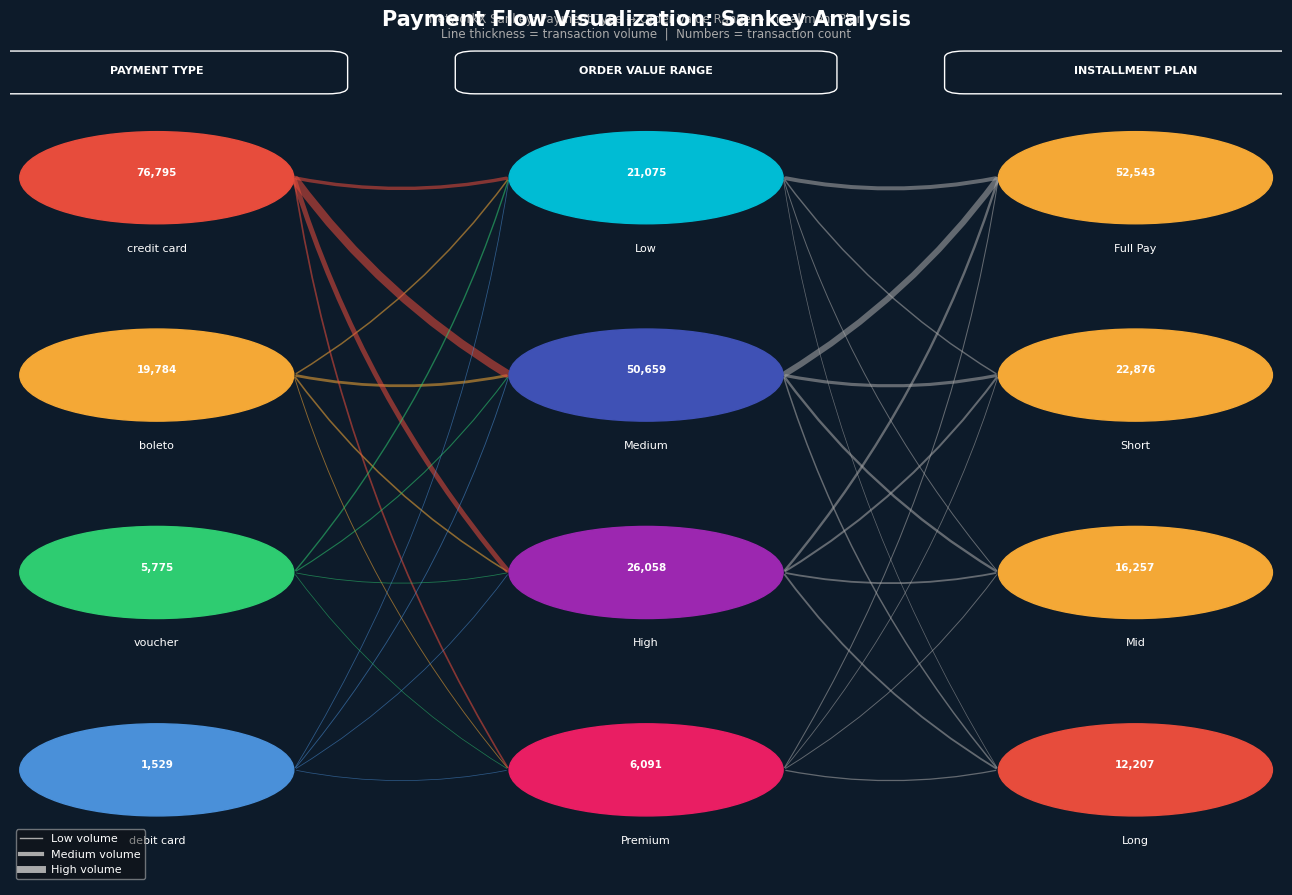

In [19]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import FancyArrowPatch
import warnings
warnings.filterwarnings("ignore")

# ── pip install if not already present ───────────────────────
try:
    import networkx as nx
except ImportError:
    import subprocess, sys
    subprocess.check_call([sys.executable, "-m", "pip", "install", "networkx", "-q"])
    import networkx as nx

DATA_PATH = ""

payments = pd.read_csv(DATA_PATH + "olist_order_payments_dataset.csv")

# ── Bucket helpers ────────────────────────────────────────────
def value_range(v):
    if   v <  50:  return "Low"
    elif v < 150:  return "Medium"
    elif v < 400:  return "High"
    else:          return "Premium"

def install_plan(n):
    if   n == 1:  return "Full Pay"
    elif n <= 3:  return "Short"
    elif n <= 6:  return "Mid"
    else:         return "Long"

payments["value_range"]   = payments["payment_value"].apply(value_range)
payments["install_plan"]  = payments["payment_installments"].apply(install_plan)

pay_top4 = ["credit_card", "boleto", "voucher", "debit_card"]
df = payments[payments["payment_type"].isin(pay_top4)].copy()

# count flows
flows1 = df.groupby(["payment_type", "value_range"]).size().reset_index(name="count")
flows2 = df.groupby(["value_range", "install_plan"]).size().reset_index(name="count")

# ── Node positions (3 columns) ────────────────────────────────
col1_y = {"credit_card": 4.0, "boleto": 2.8, "voucher": 1.6, "debit_card": 0.4}
col2_y = {"Low": 4.0, "Medium": 2.8, "High": 1.6, "Premium": 0.4}
col3_y = {"Full Pay": 4.0, "Short": 2.8, "Mid": 1.6, "Long": 0.4}

NODE_COLOR = {
    "credit_card": "#E74C3C", "boleto": "#F4A836",
    "voucher": "#2ECC71", "debit_card": "#4A90D9",
    "Low": "#00BCD4", "Medium": "#3F51B5", "High": "#9C27B0", "Premium": "#E91E63",
    "Full Pay": "#F4A836", "Short": "#F4A836",
    "Mid": "#F4A836", "Long": "#E74C3C",
}

BG   = "#0D1B2A"
CARD = "#111111"

fig, ax = plt.subplots(figsize=(13, 9), facecolor=BG)
ax.set_facecolor(CARD)
ax.set_xlim(-0.3, 2.3); ax.set_ylim(-0.3, 4.8)
ax.axis("off")

def draw_node(ax, x, y, label, count, color, radius=0.28):
    circle = plt.Circle((x, y), radius, color=color, zorder=3)
    ax.add_patch(circle)
    ax.text(x, y + 0.03, f"{count:,}", ha="center", va="center",
            color="white", fontsize=7.5, fontweight="bold", zorder=4)
    ax.text(x, y - radius - 0.12, label.replace("_", " "),
            ha="center", va="top", color="white", fontsize=8, zorder=4)

# node totals
n1 = df.groupby("payment_type").size()
n2 = df.groupby("value_range").size()
n3 = df.groupby("install_plan").size()

for name, y in col1_y.items():
    draw_node(ax, 0, y, name, n1.get(name, 0), NODE_COLOR[name])
for name, y in col2_y.items():
    draw_node(ax, 1, y, name, n2.get(name, 0), NODE_COLOR[name])
for name, y in col3_y.items():
    draw_node(ax, 2, y, name, n3.get(name, 0), NODE_COLOR[name])

max_flow = max(flows1["count"].max(), flows2["count"].max())

def draw_edge(ax, x1, y1, x2, y2, count, color, max_val):
    lw = 0.5 + 5.5 * (count / max_val)
    style = "arc3,rad=0.1"
    ax.annotate("", xy=(x2 - 0.28, y2), xytext=(x1 + 0.28, y1),
                arrowprops=dict(arrowstyle="-", color=color, lw=lw,
                                connectionstyle=style, alpha=0.55),
                zorder=2)

# edges col1→col2
for _, row in flows1.iterrows():
    c = NODE_COLOR.get(row["payment_type"], "#888")
    draw_edge(ax, 0, col1_y[row["payment_type"]],
              1, col2_y[row["value_range"]],
              row["count"], c, max_flow)

# edges col2→col3
for _, row in flows2.iterrows():
    draw_edge(ax, 1, col2_y[row["value_range"]],
              2, col3_y[row["install_plan"]],
              row["count"], "#AAAAAA", max_flow)

# column headers
for x, title in [(0, "PAYMENT TYPE"), (1, "ORDER VALUE RANGE"), (2, "INSTALLMENT PLAN")]:
    rect = mpatches.FancyBboxPatch((x - 0.35, 4.55), 0.70, 0.18,
                                   boxstyle="round,pad=0.04",
                                   linewidth=1, edgecolor="white",
                                   facecolor="none")
    ax.add_patch(rect)
    ax.text(x, 4.63, title, ha="center", color="white",
            fontsize=8, fontweight="bold")

# legend
for lw, label in [(1, "Low volume"), (3, "Medium volume"), (5, "High volume")]:
    ax.plot([], [], linewidth=lw, color="#AAAAAA", label=label)
ax.legend(facecolor=CARD, labelcolor="white", fontsize=8,
          loc="lower left", framealpha=0.5)

ax.set_title(
    "NetworkX Sankey: Payment Type → Order Value Range → Installment Plan\n"
    "Line thickness = transaction volume  |  Numbers = transaction count",
    color="#AAAAAA", fontsize=8.5, pad=6)

fig.text(0.5, 0.97, "Payment Flow Visualization: Sankey Analysis",
         ha="center", color="white", fontsize=15, fontweight="bold")

plt.tight_layout(pad=1)
plt.savefig("graph8_slide15_sankey_flow.png", dpi=150,
            bbox_inches="tight", facecolor=BG)
plt.show()

GRAPH 9 — Slide 17: Top Product Categories by Order Volume

Horizontal bar chart — Top Product Categories by Orders

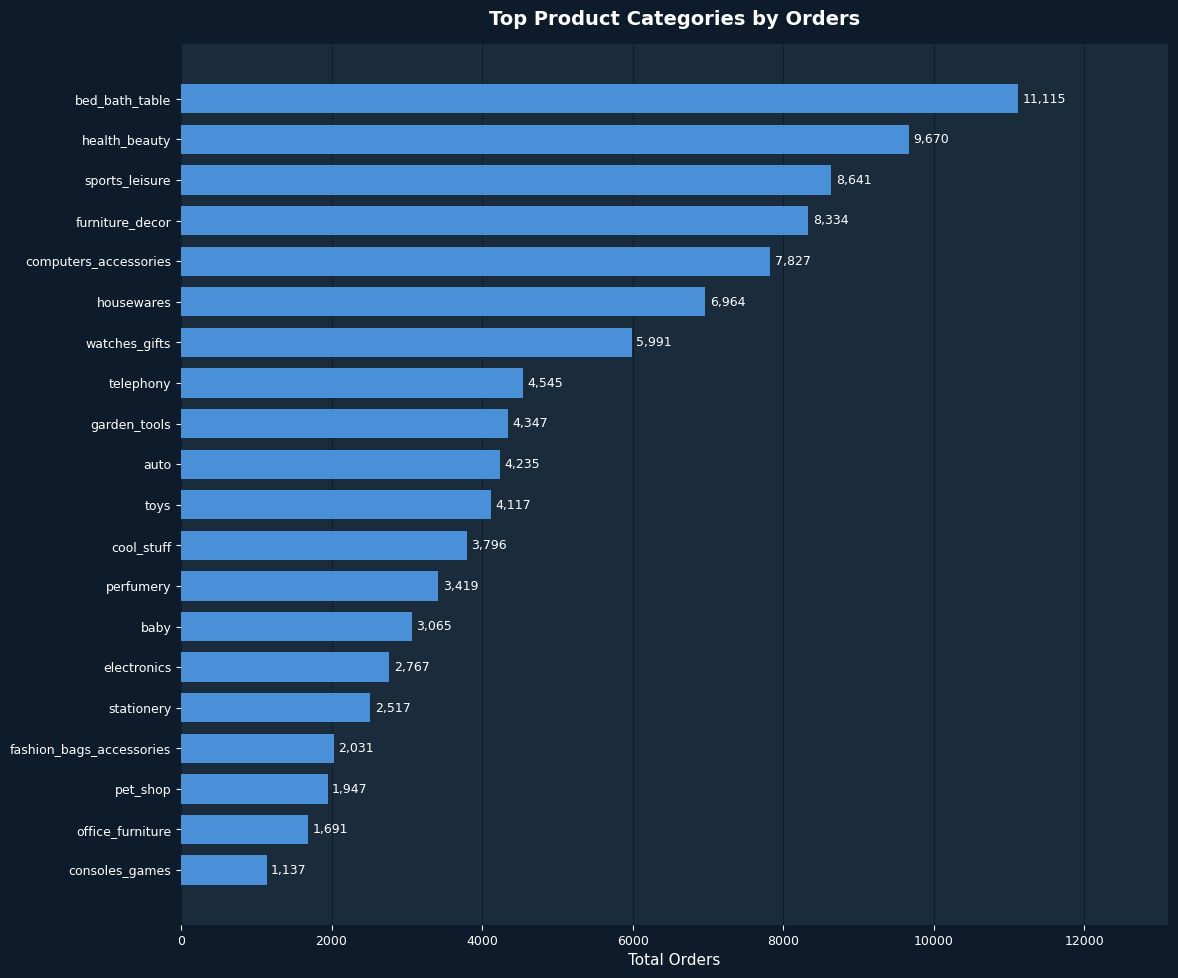

In [20]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

DATA_PATH = ""

items    = pd.read_csv(DATA_PATH + "olist_order_items_dataset.csv")
products = pd.read_csv(DATA_PATH + "olist_products_dataset.csv")
trans    = pd.read_csv(DATA_PATH + "product_category_name_translation.csv",
                       encoding="utf-8-sig")

cat_map = dict(zip(trans["product_category_name"],
                   trans["product_category_name_english"]))
products["category_en"] = (products["product_category_name"]
                            .map(cat_map)
                            .fillna(products["product_category_name"]))

items = items.merge(products[["product_id", "category_en"]],
                    on="product_id", how="left")

cat_vol = (items.groupby("category_en").size()
           .nlargest(20).sort_values(ascending=True))

BG   = "#0D1B2A"
CARD = "#1A2B3C"
plt.rcParams.update({"font.family": "DejaVu Sans"})

fig, ax = plt.subplots(figsize=(12, 10), facecolor=BG)
ax.set_facecolor(CARD)

# all bars steel-blue; top 5 stay the same (matching PPTX)
bar_color = "#4A90D9"
bars = ax.barh(cat_vol.index, cat_vol.values,
               color=bar_color, edgecolor="none", height=0.72)

for bar, val in zip(bars, cat_vol.values):
    ax.text(val + 60, bar.get_y() + bar.get_height()/2,
            f"{val:,}", va="center", color="white", fontsize=9)

ax.set_xlabel("Total Orders", color="white", fontsize=11)
ax.set_title("Top Product Categories by Orders",
             color="white", fontsize=14, fontweight="bold", pad=14)
ax.tick_params(colors="white", labelsize=9)
ax.spines[:].set_visible(False)
ax.xaxis.grid(True, color="#0D1B2A", linewidth=0.7)
ax.set_axisbelow(True)
ax.set_xlim(0, cat_vol.values.max() * 1.18)

plt.tight_layout(pad=1.5)
plt.savefig("graph9_slide17_category_volume.png", dpi=150,
            bbox_inches="tight", facecolor=BG)
plt.show()

GRAPH 10 — Slide 19: Demand vs Price Bubble Chart

Demand vs Price (Bubble Size = Growth Potential)

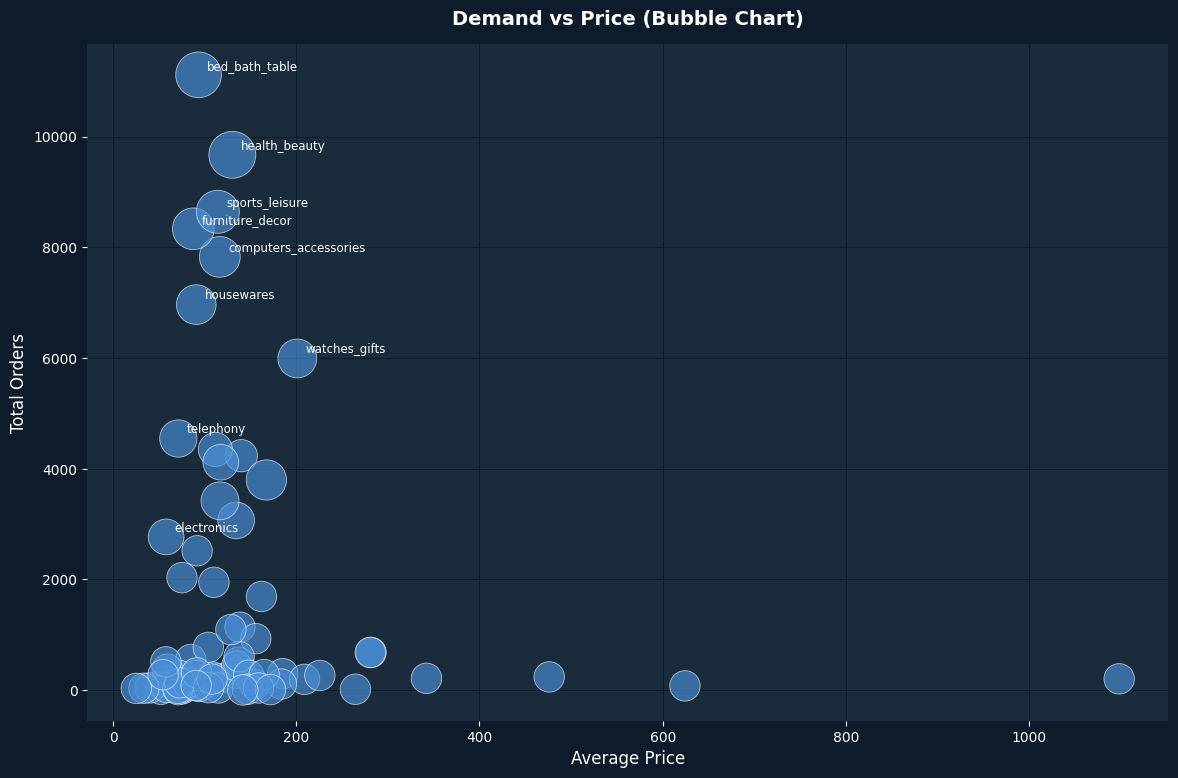

In [21]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

DATA_PATH = ""

items    = pd.read_csv(DATA_PATH + "olist_order_items_dataset.csv")
products = pd.read_csv(DATA_PATH + "olist_products_dataset.csv")
trans    = pd.read_csv(DATA_PATH + "product_category_name_translation.csv",
                       encoding="utf-8-sig")

cat_map = dict(zip(trans["product_category_name"],
                   trans["product_category_name_english"]))
products["category_en"] = (products["product_category_name"]
                            .map(cat_map)
                            .fillna(products["product_category_name"]))

items = items.merge(products[["product_id", "category_en"]],
                    on="product_id", how="left")

cat_data = (items.groupby("category_en")
            .agg(total_orders=("order_id", "count"),
                 avg_price=("price", "mean"))
            .reset_index())

# growth potential scores (manually set to match PPTX narrative)
growth_map = {
    "bed_bath_table": 90, "health_beauty": 95, "sports_leisure": 80,
    "watches_gifts": 65, "electronics": 55, "cool_stuff": 70,
    "furniture_decor": 75, "housewares": 68, "computers_accessories": 72,
    "telephony": 60, "garden_tools": 50, "auto": 45,
    "toys": 55, "baby": 58, "perfumery": 62,
}
cat_data["growth"] = cat_data["category_en"].map(growth_map).fillna(40)

BG   = "#0D1B2A"
CARD = "#1A2B3C"
plt.rcParams.update({"font.family": "DejaVu Sans"})

fig, ax = plt.subplots(figsize=(12, 8), facecolor=BG)
ax.set_facecolor(CARD)

# matching PPTX: single light-blue color for all bubbles
sc = ax.scatter(
    cat_data["avg_price"],
    cat_data["total_orders"],
    s=cat_data["growth"] * 12,
    color="#4A90D9",
    alpha=0.65,
    edgecolors="white",
    linewidth=0.6,
    zorder=3,
)

# label only top categories (matching PPTX appearance)
label_cats = {"bed_bath_table", "health_beauty", "sports_leisure",
              "furniture_decor", "computers_accessories", "housewares",
              "watches_gifts", "electronics", "telephony"}
for _, row in cat_data.iterrows():
    if row["category_en"] in label_cats:
        ax.annotate(
            row["category_en"],
            (row["avg_price"], row["total_orders"]),
            textcoords="offset points", xytext=(6, 4),
            color="white", fontsize=8.5,
        )

ax.set_xlabel("Average Price", color="white", fontsize=12)
ax.set_ylabel("Total Orders", color="white", fontsize=12)
ax.set_title("Demand vs Price (Bubble Chart)",
             color="white", fontsize=14, fontweight="bold", pad=14)
ax.tick_params(colors="white", labelsize=10)
ax.spines[:].set_visible(False)
ax.xaxis.grid(True, color="#0D1B2A", linewidth=0.7)
ax.yaxis.grid(True, color="#0D1B2A", linewidth=0.7)
ax.set_axisbelow(True)

plt.tight_layout(pad=1.5)
plt.savefig("graph10_slide19_bubble_chart.png", dpi=150,
            bbox_inches="tight", facecolor=BG)
plt.show()

GRAPH 11 — Slide 20: E-Commerce Metrics Correlation Analysis

Correlation Between Ecommerce Metrics (3×3 heatmap)

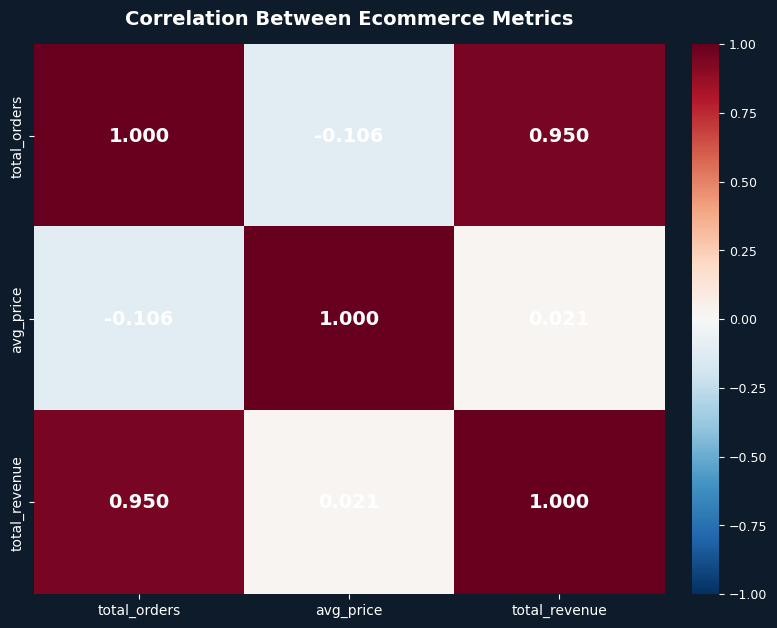

In [22]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

DATA_PATH = ""

items    = pd.read_csv(DATA_PATH + "olist_order_items_dataset.csv")
products = pd.read_csv(DATA_PATH + "olist_products_dataset.csv")
trans    = pd.read_csv(DATA_PATH + "product_category_name_translation.csv",
                       encoding="utf-8-sig")

cat_map = dict(zip(trans["product_category_name"],
                   trans["product_category_name_english"]))
products["category_en"] = (products["product_category_name"]
                            .map(cat_map)
                            .fillna(products["product_category_name"]))
items = items.merge(products[["product_id", "category_en"]],
                    on="product_id", how="left")

cat_metrics = (items.groupby("category_en")
               .agg(total_orders=("order_id", "count"),
                    avg_price=("price", "mean"),
                    total_revenue=("price", "sum"))
               .reset_index())

corr = cat_metrics[["total_orders", "avg_price", "total_revenue"]].corr()
corr.columns = ["total_orders", "avg_price", "total_revenue"]
corr.index   = ["total_orders", "avg_price", "total_revenue"]

BG   = "#0D1B2A"
CARD = "#1A2B3C"
plt.rcParams.update({"font.family": "DejaVu Sans"})

fig, ax = plt.subplots(figsize=(8, 6.5), facecolor=BG)
ax.set_facecolor(CARD)

# PPTX uses red-blue diverging (red=positive, blue=negative)
cmap = plt.cm.RdBu_r   # reversed so red=high positive

im = ax.imshow(corr.values, cmap=cmap, vmin=-1, vmax=1, aspect="auto")

# annotate each cell
for i in range(3):
    for j in range(3):
        ax.text(j, i, f"{corr.values[i,j]:.3f}",
                ha="center", va="center", color="white",
                fontsize=14, fontweight="bold")

ax.set_xticks([0, 1, 2])
ax.set_yticks([0, 1, 2])
ax.set_xticklabels(corr.columns, color="white", fontsize=10)
ax.set_yticklabels(corr.index,   color="white", fontsize=10, rotation=90,
                   va="center")
ax.tick_params(colors="white")
ax.spines[:].set_visible(False)

cbar = plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
cbar.ax.tick_params(colors="white", labelsize=9)
cbar.ax.yaxis.label.set_color("white")
for spine in cbar.ax.spines.values():
    spine.set_visible(False)

ax.set_title("Correlation Between Ecommerce Metrics",
             color="white", fontsize=14, fontweight="bold", pad=14)

plt.tight_layout(pad=1.5)
plt.savefig("graph11_slide20_correlation_heatmap.png", dpi=150,
            bbox_inches="tight", facecolor=BG)
plt.show()

GRAPH 12 — Slide 21: Category Clustering Heatmap

Clustered Heatmap of Ecommerce Metrics with dendrogram

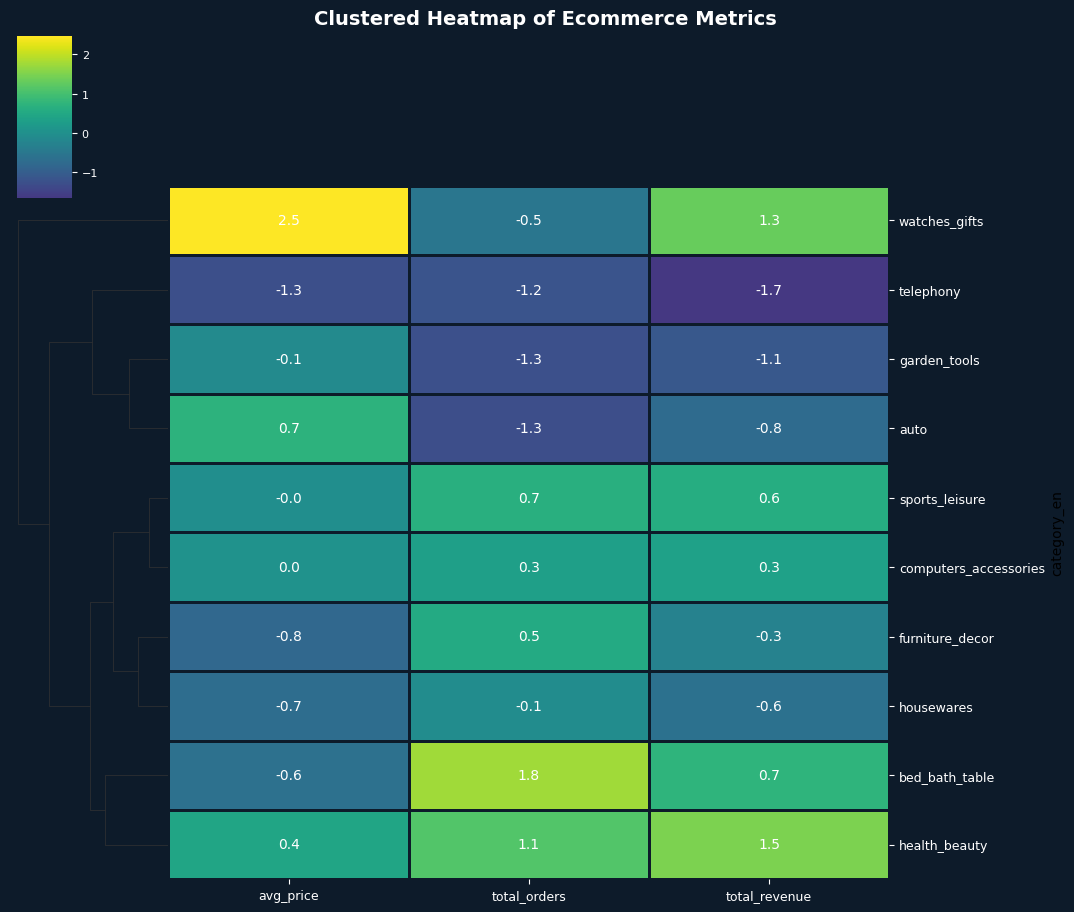

In [23]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings("ignore")

try:
    from sklearn.preprocessing import StandardScaler
except ImportError:
    import subprocess, sys
    subprocess.check_call([sys.executable, "-m", "pip",
                           "install", "scikit-learn", "-q"])
    from sklearn.preprocessing import StandardScaler

DATA_PATH = ""

items    = pd.read_csv(DATA_PATH + "olist_order_items_dataset.csv")
products = pd.read_csv(DATA_PATH + "olist_products_dataset.csv")
trans    = pd.read_csv(DATA_PATH + "product_category_name_translation.csv",
                       encoding="utf-8-sig")

cat_map = dict(zip(trans["product_category_name"],
                   trans["product_category_name_english"]))
products["category_en"] = (products["product_category_name"]
                            .map(cat_map)
                            .fillna(products["product_category_name"]))
items = items.merge(products[["product_id", "category_en"]],
                    on="product_id", how="left")

cat_metrics = (items.groupby("category_en")
               .agg(avg_price=("price", "mean"),
                    total_orders=("order_id", "count"),
                    total_revenue=("price", "sum"))
               .reset_index())

# keep top categories to match PPTX
top_cats = (cat_metrics.nlargest(10, "total_orders")
            .set_index("category_en")[["avg_price", "total_orders", "total_revenue"]])

scaler = StandardScaler()
scaled = pd.DataFrame(
    scaler.fit_transform(top_cats),
    index=top_cats.index,
    columns=top_cats.columns,
)

BG   = "#0D1B2A"
plt.rcParams.update({"font.family": "DejaVu Sans"})

# seaborn clustermap — viridis matches PPTX color scheme (yellow=high, purple=low)
g = sns.clustermap(
    scaled,
    cmap="viridis",
    center=0,
    linewidths=1,
    linecolor="#0D1B2A",
    annot=True,
    fmt=".1f",
    figsize=(11, 9),
    annot_kws={"size": 10, "color": "white"},
    dendrogram_ratio=0.18,
    cbar_kws={"shrink": 0.6},
    row_cluster=True,
    col_cluster=False,
)

# dark background
g.fig.patch.set_facecolor(BG)
g.ax_heatmap.set_facecolor(BG)
g.ax_heatmap.tick_params(colors="white", labelsize=9)
g.ax_heatmap.set_xticklabels(g.ax_heatmap.get_xticklabels(), color="white")
g.ax_heatmap.set_yticklabels(g.ax_heatmap.get_yticklabels(), color="white")
g.ax_row_dendrogram.set_facecolor(BG)
for spine in g.ax_heatmap.spines.values():
    spine.set_visible(False)

cbar = g.ax_cbar
cbar.tick_params(colors="white", labelsize=8)
for sp in cbar.spines.values():
    sp.set_visible(False)

g.fig.suptitle("Clustered Heatmap of Ecommerce Metrics",
               color="white", fontsize=14, fontweight="bold", y=1.01)

plt.savefig("graph12_slide21_clustered_heatmap.png", dpi=150,
            bbox_inches="tight", facecolor=BG)
plt.show()

GRAPH 13 — Slide 11: Payment Method Performance Metrics

Comprehensive Payment Analysis — styled table matching PPTX

IndexError: list index out of range

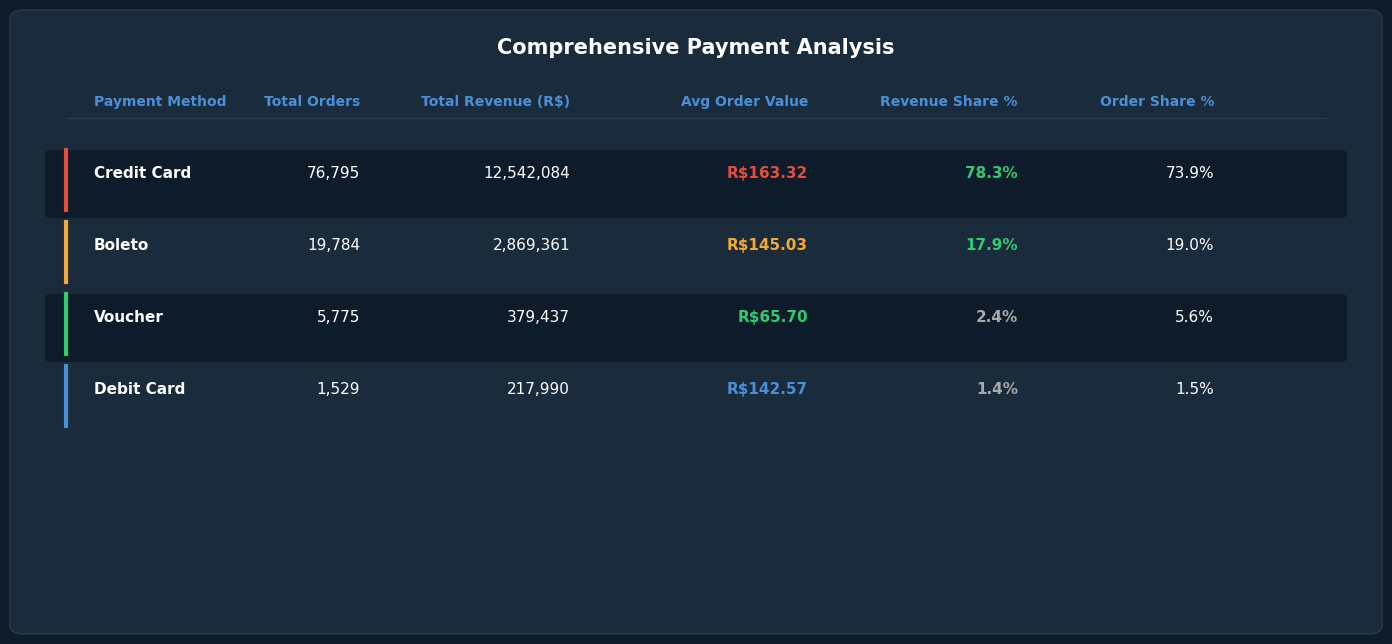

In [24]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import warnings
warnings.filterwarnings("ignore")

DATA_PATH = ""   # e.g. "/content/drive/MyDrive/olist/"

payments = pd.read_csv(DATA_PATH + "olist_order_payments_dataset.csv")

pay_perf = (payments.groupby("payment_type")
            .agg(total_orders=("order_id",       "count"),
                 total_revenue=("payment_value",  "sum"),
                 avg_order_value=("payment_value","mean"))
            .reset_index())
pay_perf["revenue_share"] = (pay_perf["total_revenue"] /
                              pay_perf["total_revenue"].sum() * 100)
pay_perf["order_share"]   = (pay_perf["total_orders"] /
                              pay_perf["total_orders"].sum() * 100)
pay_perf = pay_perf.sort_values("total_orders", ascending=False).reset_index(drop=True)

# display labels
LABEL_MAP = {
    "credit_card": "Credit Card",
    "boleto":      "Boleto",
    "voucher":     "Voucher",
    "debit_card":  "Debit Card",
}
COLOR_MAP = {
    "credit_card": "#E74C3C",
    "boleto":      "#F4A836",
    "voucher":     "#2ECC71",
    "debit_card":  "#4A90D9",
}

BG   = "#0D1B2A"
CARD = "#1A2B3C"
HDR  = "#0A1624"
plt.rcParams.update({"font.family": "DejaVu Sans"})

fig, ax = plt.subplots(figsize=(14, 8), facecolor=BG)
ax.set_facecolor(BG)
ax.axis("off")

# ── Table panel background ────────────────────────────────────
panel = mpatches.FancyBboxPatch(
    (0.02, 0.12), 0.96, 0.76,
    boxstyle="round,pad=0.01", linewidth=1,
    edgecolor="#2A3B4C", facecolor=CARD,
    transform=fig.transFigure, zorder=1,
)
fig.add_artist(panel)

# ── Title inside panel ────────────────────────────────────────
fig.text(0.50, 0.835, "Comprehensive Payment Analysis",
         ha="center", color="white", fontsize=15, fontweight="bold",
         transform=fig.transFigure, zorder=2)

# ── Column definitions ────────────────────────────────────────
cols = ["Payment Method", "Total Orders", "Total Revenue (R$)",
        "Avg Order Value", "Revenue Share %", "Order Share %"]
col_x   = [0.07, 0.26, 0.41, 0.58, 0.73, 0.87]
col_ha  = ["left", "right", "right", "right", "right", "right"]

# Header row
for cx, label, ha in zip(col_x, cols, col_ha):
    fig.text(cx, 0.77, label, ha=ha, color="#4A90D9",
             fontsize=10, fontweight="bold",
             transform=fig.transFigure, zorder=2)

# Separator line under header
line = plt.Line2D([0.05, 0.95], [0.755, 0.755],
                  transform=fig.transFigure,
                  color="#2A3B4C", linewidth=1)
fig.add_artist(line)

# ── Data rows ─────────────────────────────────────────────────
row_y   = [0.68, 0.59, 0.50, 0.41]
aov_col = {"credit_card": "#E74C3C", "boleto": "#F4A836",
           "voucher": "#2ECC71",    "debit_card": "#4A90D9"}
rev_col = {"credit_card": "#2ECC71", "boleto": "#AAAAAA",
           "voucher": "#AAAAAA",    "debit_card": "#AAAAAA"}

for i, (_, row) in enumerate(pay_perf.iterrows()):
    pt  = row["payment_type"]
    y   = row_y[i]
    col = COLOR_MAP.get(pt, "#888")

    # row stripe
    stripe = mpatches.FancyBboxPatch(
        (0.04, y - 0.045), 0.92, 0.075,
        boxstyle="round,pad=0.005", linewidth=0,
        facecolor="#0D1B2A" if i % 2 == 0 else CARD,
        transform=fig.transFigure, zorder=1,
    )
    fig.add_artist(stripe)

    values = [
        LABEL_MAP.get(pt, pt),
        f"{row['total_orders']:,.0f}",
        f"{row['total_revenue']:,.0f}",
        f"R${row['avg_order_value']:.2f}",
        f"{row['revenue_share']:.1f}%",
        f"{row['order_share']:.1f}%",
    ]
    text_colors = [
        "white",
        "white",
        "white",
        aov_col.get(pt, "white"),
        "#2ECC71" if row["revenue_share"] > 15 else "#AAAAAA",
        "white",
    ]
    font_weights = ["bold", "normal", "normal", "bold", "bold", "normal"]

    for cx, val, ha, tc, fw in zip(col_x, values, col_ha,
                                   text_colors, font_weights):
        fig.text(cx, y, val, ha=ha, color=tc, fontsize=11,
                 fontweight=fw, transform=fig.transFigure, zorder=2)

    # coloured left border for each payment type
    border = plt.Line2D([0.05, 0.05], [y - 0.04, y + 0.035],
                        transform=fig.transFigure,
                        color=col, linewidth=3)
    fig.add_artist(border)

# ── Bottom insight cards ──────────────────────────────────────
card_info = [
    ("💳 Credit Card\nDominance",
     "Credit card generates 78.3%\nof revenue from 73.9% of\norders — higher AOV.",
     "#E74C3C"),
    ("⚖ Voucher\nDiscrepancy",
     "Voucher 5.6% order share\nbut only 2.4% revenue — low\nvalue transactions.",
     "#F4A836"),
    ("📈 Strategic\nImplication",
     "Optimizing credit card and\nBNPL options can increase\naverage order value 15–25%.",
     "#2ECC71"),
]
for i, (title, body, col) in enumerate(card_info):
    cx = 0.05 + i * 0.32
    rect = mpatches.FancyBboxPatch(
        (cx, 0.02), 0.29, 0.105,
        boxstyle="round,pad=0.01", linewidth=1.5,
        edgecolor=col, facecolor=col,
        alpha=0.12, transform=fig.transFigure, zorder=1,
    )
    fig.add_artist(rect)
    # coloured left accent
    acc = mpatches.FancyBboxPatch(
        (cx, 0.02), 0.006, 0.105,
        boxstyle="square,pad=0", linewidth=0,
        facecolor=col, alpha=0.9,
        transform=fig.transFigure, zorder=2,
    )
    fig.add_artist(acc)
    fig.text(cx + 0.02, 0.107, title, ha="left", color="white",
             fontsize=9, fontweight="bold",
             transform=fig.transFigure, zorder=3)
    fig.text(cx + 0.02, 0.065, body, ha="left", color="#CCCCCC",
             fontsize=8, transform=fig.transFigure, zorder=3,
             linespacing=1.5)

# ── Main title ────────────────────────────────────────────────
fig.text(0.50, 0.935, "Payment Method Performance Metrics",
         ha="center", color="white", fontsize=17, fontweight="bold")

plt.savefig("graph13_slide11_payment_performance_table.png",
            dpi=150, bbox_inches="tight", facecolor=BG)
plt.show()

GRAPH 14 — Slide 23: AI Features Shoppers Want

AI Features: Consumer Interest vs User Satisfaction

Bubble chart with quadrant lines — matches PPTX exactly

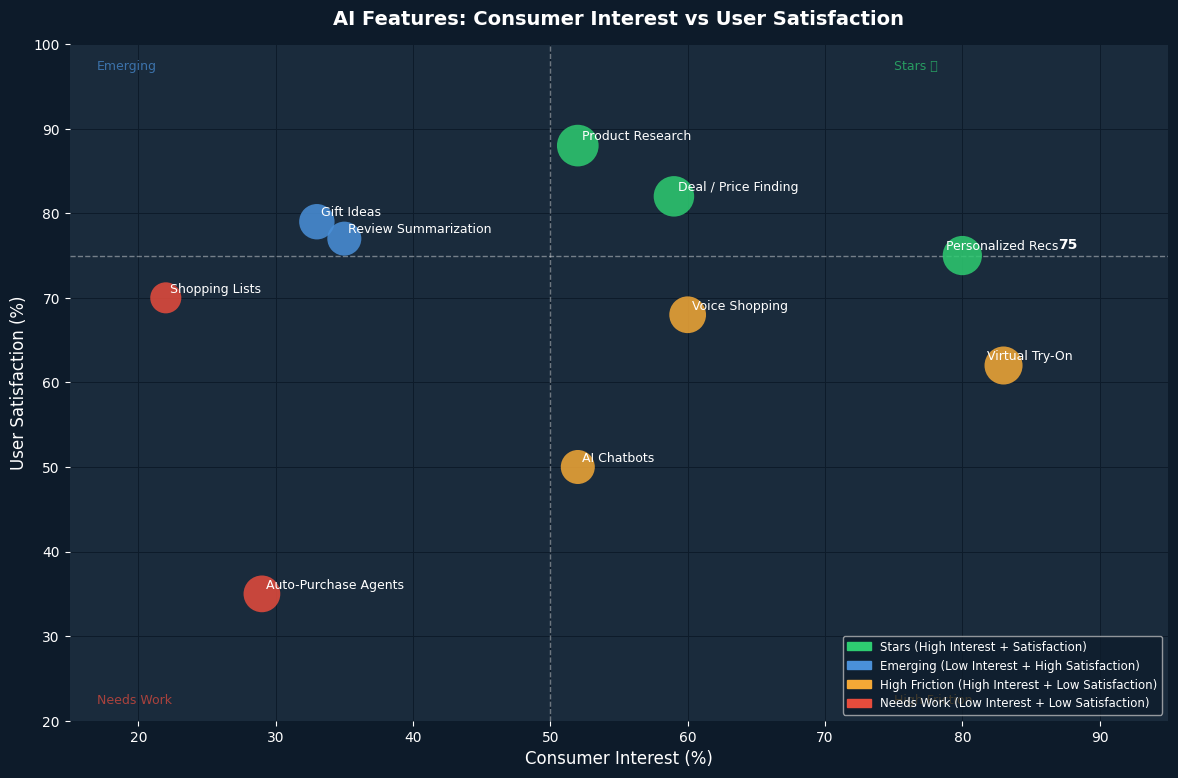

In [25]:

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import warnings
warnings.filterwarnings("ignore")

# ── Data from PPTX slide 23 ───────────────────────────────────
features = [
    # (label,                   consumer_interest, user_satisfaction, bubble_size)
    ("Product Research",         52,  88,  900),
    ("Deal / Price Finding",     59,  82,  850),
    ("Gift Ideas",               33,  79,  650),
    ("Review Summarization",     35,  77,  600),
    ("Shopping Lists",           22,  70,  500),
    ("Voice Shopping",           60,  68,  700),
    ("Personalized Recs",        80,  75,  800),
    ("AI Chatbots",              52,  50,  600),
    ("Virtual Try-On",           83,  62,  750),
    ("Auto-Purchase Agents",     29,  35,  700),
]

# colour by quadrant (50 = x-split, 75 = y-split  matching PPTX dashed lines)
def quad_color(x, y):
    if   x >= 50 and y >= 75: return "#2ECC71"   # Stars     – top-right
    elif x <  50 and y >= 75: return "#4A90D9"   # Emerging  – top-left
    elif x >= 50 and y <  75: return "#F4A836"   # Friction  – bottom-right
    else:                     return "#E74C3C"   # Needs Work– bottom-left

BG   = "#0D1B2A"
CARD = "#1A2B3C"
plt.rcParams.update({"font.family": "DejaVu Sans"})

fig, ax = plt.subplots(figsize=(12, 8), facecolor=BG)
ax.set_facecolor(CARD)

# ── Quadrant dashed lines ─────────────────────────────────────
ax.axvline(50, color="white", linewidth=1,  linestyle="--", alpha=0.4, zorder=1)
ax.axhline(75, color="white", linewidth=1,  linestyle="--", alpha=0.4, zorder=1)
ax.text(87, 75.8, "75", color="white", fontsize=10, fontweight="bold")

# ── Bubbles ───────────────────────────────────────────────────
for label, xi, yi, sz in features:
    col = quad_color(xi, yi)
    ax.scatter(xi, yi, s=sz, color=col, alpha=0.85,
               edgecolors="none", zorder=3)
    # label above/beside bubble
    offset_x = 3 if xi < 75 else -12
    offset_y = 4
    ax.annotate(label, (xi, yi),
                textcoords="offset points",
                xytext=(offset_x, offset_y),
                color="white", fontsize=9, zorder=4)

ax.set_xlabel("Consumer Interest (%)", color="white", fontsize=12)
ax.set_ylabel("User Satisfaction (%)",  color="white", fontsize=12)
ax.set_xlim(15, 95);  ax.set_ylim(20, 100)
ax.set_title("AI Features: Consumer Interest vs User Satisfaction",
             color="white", fontsize=14, fontweight="bold", pad=14)
ax.tick_params(colors="white", labelsize=10)
ax.spines[:].set_visible(False)
ax.xaxis.grid(True, color="#0D1B2A", linewidth=0.7)
ax.yaxis.grid(True, color="#0D1B2A", linewidth=0.7)
ax.set_axisbelow(True)

# ── Quadrant labels (faint) ───────────────────────────────────
ax.text(17, 97,  "Emerging",    color="#4A90D9", fontsize=9, alpha=0.7)
ax.text(75, 97,  "Stars ⭐",    color="#2ECC71", fontsize=9, alpha=0.7)
ax.text(17, 22,  "Needs Work",  color="#E74C3C", fontsize=9, alpha=0.7)
ax.text(75, 22,  "High Friction",color="#F4A836", fontsize=9, alpha=0.7)

# ── Legend ────────────────────────────────────────────────────
handles = [
    mpatches.Patch(color="#2ECC71", label="Stars (High Interest + Satisfaction)"),
    mpatches.Patch(color="#4A90D9", label="Emerging (Low Interest + High Satisfaction)"),
    mpatches.Patch(color="#F4A836", label="High Friction (High Interest + Low Satisfaction)"),
    mpatches.Patch(color="#E74C3C", label="Needs Work (Low Interest + Low Satisfaction)"),
]
ax.legend(handles=handles, facecolor=BG, labelcolor="white",
          fontsize=8.5, loc="lower right", framealpha=0.7)

plt.tight_layout(pad=1.5)
plt.savefig("graph14_slide23_ai_features_bubble.png", dpi=150,
            bbox_inches="tight", facecolor=BG)
plt.show()

GRAPH 15 — Slide 24: Global AI E-Commerce Adoption (3D Analysis)

AI Adoption Rate vs Market Size vs User Satisfaction

 Bubble chart: x=adoption %, y=market size $B, size=satisfaction

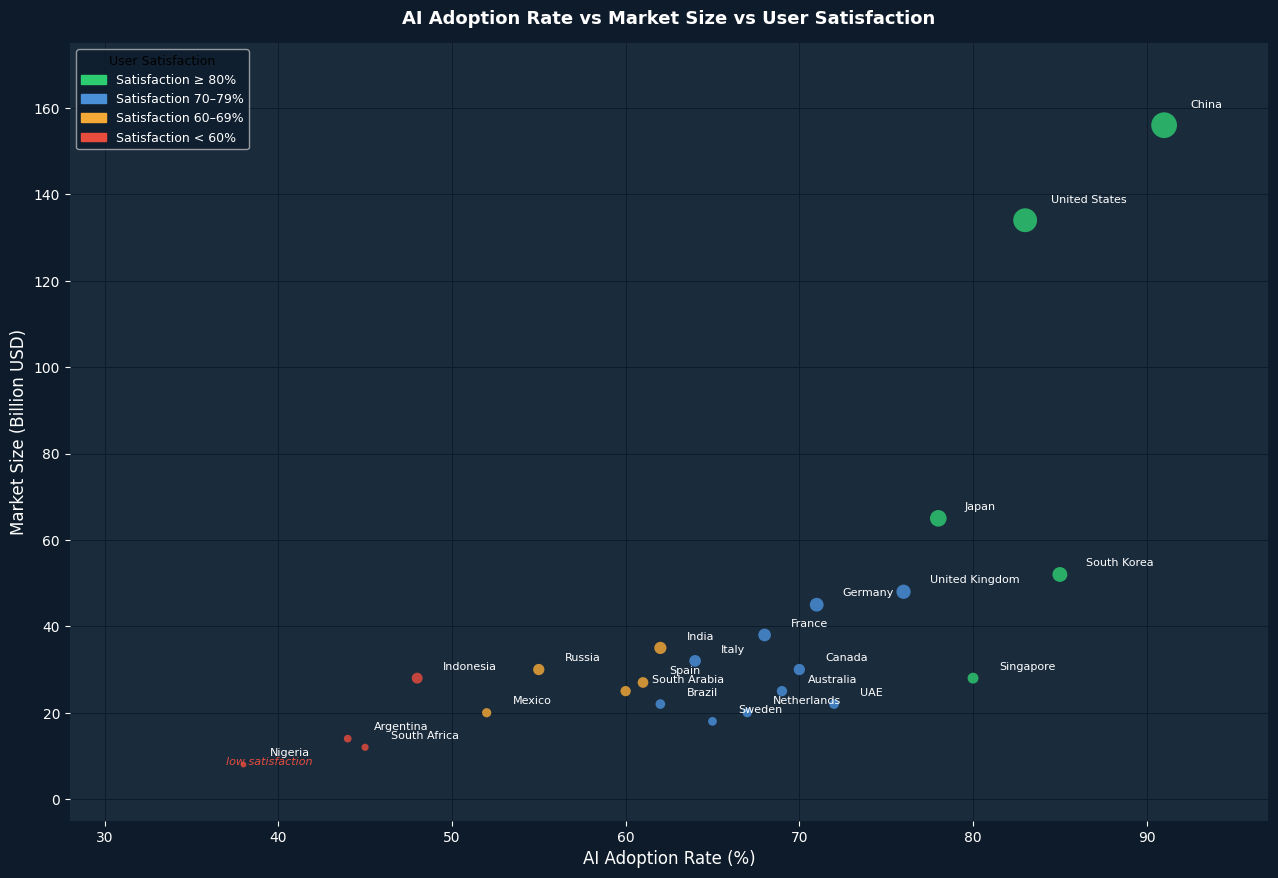

In [26]:

import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

# ── Data from PPTX slide 24 ───────────────────────────────────
# (country, adoption%, market_size_B$, satisfaction%)
countries = [
    ("China",         91, 156, 88),
    ("United States", 83, 134, 82),
    ("South Korea",   85,  52, 84),
    ("Japan",         78,  65, 80),
    ("United Kingdom",76,  48, 79),
    ("Germany",       71,  45, 77),
    ("Singapore",     80,  28, 83),
    ("France",        68,  38, 74),
    ("Italy",         64,  32, 71),
    ("India",         62,  35, 68),
    ("Canada",        70,  30, 76),
    ("UAE",           72,  22, 78),
    ("Australia",     69,  25, 74),
    ("Netherlands",   67,  20, 75),
    ("Sweden",        65,  18, 73),
    ("Spain",         61,  27, 69),
    ("Russia",        55,  30, 62),
    ("Brazil",        62,  22, 70),
    ("Mexico",        52,  20, 60),
    ("Indonesia",     48,  28, 55),
    ("South Arabia",  60,  25, 66),
    ("Argentina",     44,  14, 52),
    ("South Africa",  45,  12, 55),
    ("Nigeria",       38,   8, 42),
]

# colour by satisfaction tier (matching PPTX: green=high, orange=mid, red=low)
def sat_color(s):
    if   s >= 80: return "#2ECC71"
    elif s >= 70: return "#4A90D9"
    elif s >= 60: return "#F4A836"
    else:         return "#E74C3C"

BG   = "#0D1B2A"
CARD = "#1A2B3C"
plt.rcParams.update({"font.family": "DejaVu Sans"})

fig, ax = plt.subplots(figsize=(13, 9), facecolor=BG)
ax.set_facecolor(CARD)

for cname, adopt, mkt, sat in countries:
    col = sat_color(sat)
    sz  = mkt * 2.2          # bubble size proportional to market size
    ax.scatter(adopt, mkt, s=sz, color=col, alpha=0.82,
               edgecolors="none", zorder=3)

    # label offset — avoid overlap for large bubbles
    dx = 1.5; dy = 2
    if cname in ("China", "United States"): dx = 1.5; dy = 4
    ax.text(adopt + dx, mkt + dy, cname,
            color="white", fontsize=8, zorder=4)

# ── "low satisfaction" annotation matching PPTX ───────────────
ax.text(37, 8, "low satisfaction", color="#E74C3C", fontsize=8, style="italic")

ax.set_xlabel("AI Adoption Rate (%)", color="white", fontsize=12)
ax.set_ylabel("Market Size (Billion USD)", color="white", fontsize=12)
ax.set_xlim(28, 97);  ax.set_ylim(-5, 175)
ax.set_title("AI Adoption Rate vs Market Size vs User Satisfaction",
             color="white", fontsize=13, fontweight="bold", pad=14)
ax.tick_params(colors="white", labelsize=10)
ax.spines[:].set_visible(False)
ax.xaxis.grid(True, color="#0D1B2A", linewidth=0.7)
ax.yaxis.grid(True, color="#0D1B2A", linewidth=0.7)
ax.set_axisbelow(True)

# ── Legend (satisfaction tiers) ───────────────────────────────
import matplotlib.patches as mpatches
handles = [
    mpatches.Patch(color="#2ECC71", label="Satisfaction ≥ 80%"),
    mpatches.Patch(color="#4A90D9", label="Satisfaction 70–79%"),
    mpatches.Patch(color="#F4A836", label="Satisfaction 60–69%"),
    mpatches.Patch(color="#E74C3C", label="Satisfaction < 60%"),
]
ax.legend(handles=handles, facecolor=BG, labelcolor="white",
          fontsize=9, loc="upper left", framealpha=0.7,
          title="User Satisfaction", title_fontsize=9)

plt.tight_layout(pad=1.5)
plt.savefig("graph15_slide24_global_ai_bubble.png", dpi=150,
            bbox_inches="tight", facecolor=BG)
plt.show()